# **Project Name**    - PhonePe Transaction Insights



##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Team Member 1 -** Koushik Gupta


# **Project Summary -**

The rapid growth of digital payment platforms has transformed the way financial transactions are conducted in India, with applications like PhonePe playing a significant role in driving this shift. This project, titled “PhonePe Transaction Insights,” focuses on analyzing large-scale transaction data to uncover meaningful patterns related to user behavior, transaction categories, and geographical distribution. The primary objective is to extract, process, and visualize data in order to generate actionable insights that can support business decision-making in the digital payments ecosystem.

The dataset for this project is sourced from the PhonePe Pulse GitHub repository, which contains structured JSON files representing transaction, user, and insurance data across different states and districts of India. The data is organized hierarchically based on year and quarter, requiring careful extraction and transformation. Python is used as the primary tool for data extraction, where libraries such as Pandas and JSON are utilized to parse nested data structures and convert them into tabular formats suitable for analysis.

Once the data is extracted and cleaned, it is stored in a relational database management system using SQL. Multiple tables are created to organize the data effectively, including aggregated, map-based, and top-performing datasets. SQL queries are then used to perform data analysis, such as identifying top states by transaction volume, analyzing category-wise contributions, and examining trends over time. This step ensures efficient handling of large datasets and enables structured querying for meaningful insights.

Further analysis is carried out using Python’s data visualization libraries, including Matplotlib and Seaborn. Various types of charts, such as bar graphs, pie charts, and line plots, are created to represent trends and comparisons in an intuitive manner. These visualizations help in understanding the distribution of transactions, identifying high-performing regions, and observing changes in user engagement over time.

To enhance the usability of the analysis, an interactive dashboard is developed using Streamlit. The dashboard provides a user-friendly interface that allows users to explore the data dynamically through filters such as state, year, and transaction category. This enables real-time interaction with the data and facilitates better interpretation of insights without requiring technical expertise.

The project also emphasizes storytelling through data by presenting key insights derived from the analysis. For instance, it highlights regions with high transaction activity, identifies dominant payment categories, and tracks growth trends across different time periods. These insights can help businesses optimize their marketing strategies, improve user engagement, and make informed decisions regarding product development.

Overall, this project demonstrates a complete data analysis pipeline, starting from data extraction and transformation to visualization and dashboard deployment. It showcases practical skills in Python, SQL, and Streamlit while applying analytical thinking to a real-world financial dataset. The project not only provides a deeper understanding of digital payment trends but also highlights the importance of data-driven decision-making in modern financial systems.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


**With the increasing reliance on digital payment systems like PhonePe, understanding the dynamics of transactions, user engagement, and insurance-related data is crucial for improving services and targeting users effectively. This project aims to analyze and visualize aggregated values of payment categories, create maps for total values at state and district levels, and identify top-performing states, districts, and pin codes.**

#### **Define Your Business Objective?**

1. **Customer Segmentation:** Identify distinct user groups based on spending habits to tailor marketing strategies.
2. **Fraud Detection:** Analyze transaction patterns to spot and prevent fraudulent activities.
3. **Geographical Insights:** Understand payment trends at state and district levels for targeted marketing.
4. **Payment Performance:** Evaluate the popularity of different payment categories for strategic investments.
5. **User Engagement:** Monitor user activity to develop strategies that enhance retention and satisfaction.
6. **Product Development:** Use data insights to inform the creation of new features and services.
7. **Insurance Insights:** Analyze insurance transaction data to improve product offerings and customer experience.
8. **Marketing Optimization:** Tailor marketing campaigns based on user behavior and transaction patterns.
9. **Trend Analysis:** Examine transaction trends over time to anticipate demand fluctuations.
10. **Competitive Benchmarking:** Compare performance against competitors to identify areas for improvement.


# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [135]:
# Import Libraries

import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Clone Github

In [136]:
# Load Dataset
import os
import subprocess

repo_url = 'https://github.com/PhonePe/pulse.git'
repo_dir = 'pulse'

if os.path.exists(repo_dir):
    print(f'Repository already exists: {repo_dir}')
else:
    subprocess.run(['git', 'clone', repo_url, repo_dir], check=True)
    print(f'Cloned repository into: {repo_dir}')


fatal: destination path 'pulse' already exists and is not an empty directory.


### Dataset First View

In [137]:
# Dataset First Look
os.listdir('pulse/data')

['aggregated', 'map', 'top']

### JSON View

In [138]:
path = 'pulse/data/aggregated/transaction/country/india/2018/1.json'

with open(path, 'r') as f:
    data = json.load(f)

data

{'success': True,
 'code': 'SUCCESS',
 'data': {'from': 1514745000000,
  'to': 1522175400000,
  'transactionData': [{'name': 'Recharge & bill payments',
    'paymentInstruments': [{'type': 'TOTAL',
      'count': 72550406,
      'amount': 14472713558.652578}]},
   {'name': 'Peer-to-peer payments',
    'paymentInstruments': [{'type': 'TOTAL',
      'count': 46982705,
      'amount': 147245883542.77402}]},
   {'name': 'Merchant payments',
    'paymentInstruments': [{'type': 'TOTAL',
      'count': 5368669,
      'amount': 4656678915.140091}]},
   {'name': 'Financial Services',
    'paymentInstruments': [{'type': 'TOTAL',
      'count': 3762820,
      'amount': 815853105.1000277}]},
   {'name': 'Others',
    'paymentInstruments': [{'type': 'TOTAL',
      'count': 5761576,
      'amount': 4643217301.269438}]}]},
 'responseTimestamp': 1630346628866}

# Data Extraction and CSV Generation

In [139]:
path = 'pulse/data/aggregated/transaction/country/india'

agg_trans_list = []

for year in os.listdir(path):
    if not year.isdigit():
        continue
    year_path = os.path.join(path, year)

    for file in os.listdir(year_path):
        file_path = os.path.join(year_path, file)
        if not os.path.isfile(file_path):
            continue

        with open(file_path, 'r') as f:
            data = json.load(f)

            try:
                for i in data['data']['transactionData']:
                    for j in i['paymentInstruments']:
                        agg_trans_list.append({
                            "Year": int(year),
                            "Quarter": int(file.replace('.json','')),
                            "Transaction_Type": i['name'],
                            "Transaction_Count": j['count'],
                            "Transaction_Amount": j['amount']
                        })
            except:
                # Skip files with missing data
                pass

df_agg_trans = pd.DataFrame(agg_trans_list)

df_agg_trans.shape

(140, 5)

In [140]:
# Save aggregated transaction country data to CSV
df_agg_trans.to_csv('aggregated_transaction_country.csv', index=False)
print("Saved aggregated_transaction_country.csv")

Saved aggregated_transaction_country.csv


In [141]:
# Extract aggregated transaction state data
path_state = 'pulse/data/aggregated/transaction/country/india/state'

agg_trans_state_list = []

for state in os.listdir(path_state):
    state_name = state.replace('-', ' ').title()
    state_dir = os.path.join(path_state, state)
    
    for year in os.listdir(state_dir):
        if not year.isdigit():
            continue
        year_dir = os.path.join(state_dir, year)
        
        for file in os.listdir(year_dir):
            if not file.endswith('.json'):
                continue
            file_path = os.path.join(year_dir, file)
            
            with open(file_path, 'r') as f:
                data = json.load(f)
                
                try:
                    for i in data['data']['transactionData']:
                        for j in i['paymentInstruments']:
                            agg_trans_state_list.append({
                                "State": state_name,
                                "Year": int(year),
                                "Quarter": int(file.split('.')[0]),
                                "Transaction_Type": i['name'],
                                "Transaction_Count": j['count'],
                                "Transaction_Amount": j['amount']
                            })
                except:
                    pass

df_agg_trans_state = pd.DataFrame(agg_trans_state_list)
df_agg_trans_state.to_csv('aggregated_transaction_state.csv', index=False)
print("Saved aggregated_transaction_state.csv, shape:", df_agg_trans_state.shape)

Saved aggregated_transaction_state.csv, shape: (5034, 6)


In [142]:
# Extract aggregated user country data
path_user_country = 'pulse/data/aggregated/user/country/india'

agg_user_country_list = []

for year in os.listdir(path_user_country):
    if not year.isdigit():
        continue
    year_path = os.path.join(path_user_country, year)
    
    for file in os.listdir(year_path):
        if not file.endswith('.json'):
            continue
        file_path = os.path.join(year_path, file)
        
        with open(file_path, 'r') as f:
            data = json.load(f)
            
            try:
                aggregated = data['data']['aggregated']
                agg_user_country_list.append({
                    "Year": int(year),
                    "Quarter": int(file.split('.')[0]),
                    "Registered_Users": aggregated['registeredUsers'],
                    "App_Opens": aggregated['appOpens']
                })
            except:
                pass

df_agg_user_country = pd.DataFrame(agg_user_country_list)
df_agg_user_country.to_csv('aggregated_user_country.csv', index=False)
print("Saved aggregated_user_country.csv, shape:", df_agg_user_country.shape)

Saved aggregated_user_country.csv, shape: (28, 4)


In [143]:
# Extract aggregated user state data
path_user_state = 'pulse/data/aggregated/user/country/india/state'

agg_user_state_list = []

for state in os.listdir(path_user_state):
    state_name = state.replace('-', ' ').title()
    state_dir = os.path.join(path_user_state, state)
    
    for year in os.listdir(state_dir):
        if not year.isdigit():
            continue
        year_dir = os.path.join(state_dir, year)
        
        for file in os.listdir(year_dir):
            if not file.endswith('.json'):
                continue
            file_path = os.path.join(year_dir, file)
            
            with open(file_path, 'r') as f:
                data = json.load(f)
                
                try:
                    aggregated = data['data']['aggregated']
                    agg_user_state_list.append({
                        "State": state_name,
                        "Year": int(year),
                        "Quarter": int(file.split('.')[0]),
                        "Registered_Users": aggregated['registeredUsers'],
                        "App_Opens": aggregated['appOpens']
                    })
                except:
                    pass

df_agg_user_state = pd.DataFrame(agg_user_state_list)
df_agg_user_state.to_csv('aggregated_user_state.csv', index=False)
print("Saved aggregated_user_state.csv, shape:", df_agg_user_state.shape)

Saved aggregated_user_state.csv, shape: (1008, 5)


In [144]:
# Extract aggregated insurance country data
path_ins_country = 'pulse/data/aggregated/insurance/country/india'

agg_ins_country_list = []

for year in os.listdir(path_ins_country):
    if not year.isdigit():
        continue
    year_path = os.path.join(path_ins_country, year)
    
    for file in os.listdir(year_path):
        if not file.endswith('.json'):
            continue
        file_path = os.path.join(year_path, file)
        
        with open(file_path, 'r') as f:
            data = json.load(f)
            
            try:
                for i in data['data']['transactionData']:
                    for j in i['paymentInstruments']:
                        agg_ins_country_list.append({
                            "Year": int(year),
                            "Quarter": int(file.split('.')[0]),
                            "Insurance_Type": i['name'],
                            "Transaction_Count": j['count'],
                            "Transaction_Amount": j['amount']
                        })
            except:
                pass

df_agg_ins_country = pd.DataFrame(agg_ins_country_list)
df_agg_ins_country.to_csv('aggregated_insurance_country.csv', index=False)
print("Saved aggregated_insurance_country.csv, shape:", df_agg_ins_country.shape)

Saved aggregated_insurance_country.csv, shape: (19, 5)


In [145]:
# Extract aggregated insurance state data
path_ins_state = 'pulse/data/aggregated/insurance/country/india/state'

agg_ins_state_list = []

for state in os.listdir(path_ins_state):
    state_name = state.replace('-', ' ').title()
    state_dir = os.path.join(path_ins_state, state)
    
    for year in os.listdir(state_dir):
        if not year.isdigit():
            continue
        year_dir = os.path.join(state_dir, year)
        
        for file in os.listdir(year_dir):
            if not file.endswith('.json'):
                continue
            file_path = os.path.join(year_dir, file)
            
            with open(file_path, 'r') as f:
                data = json.load(f)
                
                try:
                    for i in data['data']['transactionData']:
                        for j in i['paymentInstruments']:
                            agg_ins_state_list.append({
                                "State": state_name,
                                "Year": int(year),
                                "Quarter": int(file.split('.')[0]),
                                "Insurance_Type": i['name'],
                                "Transaction_Count": j['count'],
                                "Transaction_Amount": j['amount']
                            })
                except:
                    pass

df_agg_ins_state = pd.DataFrame(agg_ins_state_list)
df_agg_ins_state.to_csv('aggregated_insurance_state.csv', index=False)
print("Saved aggregated_insurance_state.csv, shape:", df_agg_ins_state.shape)

Saved aggregated_insurance_state.csv, shape: (682, 6)


In [146]:
# Extract top transaction data
path_top_trans = 'pulse/data/top/transaction/country/india'

top_trans_list = []

for year in os.listdir(path_top_trans):
    if not year.isdigit():
        continue
    year_path = os.path.join(path_top_trans, year)
    
    for file in os.listdir(year_path):
        if not file.endswith('.json'):
            continue
        file_path = os.path.join(year_path, file)
        
        with open(file_path, 'r') as f:
            data = json.load(f)
            
            try:
                # States
                for item in data['data']['states']:
                    top_trans_list.append({
                        "Year": int(year),
                        "Quarter": int(file.split('.')[0]),
                        "Type": "State",
                        "Entity_Name": item['entityName'].replace('-', ' ').title(),
                        "Transaction_Count": item['metric']['count'],
                        "Transaction_Amount": item['metric']['amount']
                    })
                # Districts
                for item in data['data']['districts']:
                    top_trans_list.append({
                        "Year": int(year),
                        "Quarter": int(file.split('.')[0]),
                        "Type": "District",
                        "Entity_Name": item['entityName'].replace('-', ' ').title(),
                        "Transaction_Count": item['metric']['count'],
                        "Transaction_Amount": item['metric']['amount']
                    })
                # Pincodes
                for item in data['data']['pincodes']:
                    top_trans_list.append({
                        "Year": int(year),
                        "Quarter": int(file.split('.')[0]),
                        "Type": "Pincode",
                        "Entity_Name": item['entityName'],
                        "Transaction_Count": item['metric']['count'],
                        "Transaction_Amount": item['metric']['amount']
                    })
            except:
                pass

df_top_trans = pd.DataFrame(top_trans_list)
df_top_trans.to_csv('top_transaction.csv', index=False)
print("Saved top_transaction.csv, shape:", df_top_trans.shape)

Saved top_transaction.csv, shape: (840, 6)


In [147]:
# Extract top user data
path_top_user = 'pulse/data/top/user/country/india'

top_user_list = []

for year in os.listdir(path_top_user):
    if not year.isdigit():
        continue
    year_path = os.path.join(path_top_user, year)
    
    for file in os.listdir(year_path):
        if not file.endswith('.json'):
            continue
        file_path = os.path.join(year_path, file)
        
        with open(file_path, 'r') as f:
            data = json.load(f)
            
            try:
                # States
                for item in data['data']['states']:
                    top_user_list.append({
                        "Year": int(year),
                        "Quarter": int(file.split('.')[0]),
                        "Type": "State",
                        "Entity_Name": item['name'].replace('-', ' ').title(),
                        "Registered_Users": item['registeredUsers']
                    })
                # Districts
                for item in data['data']['districts']:
                    top_user_list.append({
                        "Year": int(year),
                        "Quarter": int(file.split('.')[0]),
                        "Type": "District",
                        "Entity_Name": item['name'].replace('-', ' ').title(),
                        "Registered_Users": item['registeredUsers']
                    })
                # Pincodes
                for item in data['data']['pincodes']:
                    top_user_list.append({
                        "Year": int(year),
                        "Quarter": int(file.split('.')[0]),
                        "Type": "Pincode",
                        "Entity_Name": item['name'],
                        "Registered_Users": item['registeredUsers']
                    })
            except:
                pass

df_top_user = pd.DataFrame(top_user_list)
df_top_user.to_csv('top_user.csv', index=False)
print("Saved top_user.csv, shape:", df_top_user.shape)

Saved top_user.csv, shape: (840, 5)


In [148]:
# Check top user structure
import os
print(os.listdir('pulse/data/top/user/country/india/2024'))
with open('pulse/data/top/user/country/india/2024/1.json', 'r') as f:
    import json
    data = json.load(f)
    print(data['data'].keys())

['1.json', '2.json', '3.json', '4.json']
dict_keys(['states', 'districts', 'pincodes'])


In [149]:
with open('pulse/data/top/user/country/india/2024/1.json', 'r') as f:
    data = json.load(f)
    print(data['data']['states'][0])

{'name': 'maharashtra', 'registeredUsers': 68016876}


In [150]:
print(len(data['data']['states']))
print(len(data['data']['districts']))
print(data['data']['districts'][0] if data['data']['districts'] else 'No districts')

10
10
{'name': 'bengaluru urban', 'registeredUsers': 17506580}


In [151]:
print(len(data['data']['pincodes']))
print(data['data']['pincodes'][0] if data['data']['pincodes'] else 'No pincodes')

10
{'name': '201301', 'registeredUsers': 984239}


In [152]:
# Extract top insurance data
path_top_ins = 'pulse/data/top/insurance/country/india'

top_ins_list = []

for year in os.listdir(path_top_ins):
    if not year.isdigit():
        continue
    year_path = os.path.join(path_top_ins, year)
    
    for file in os.listdir(year_path):
        if not file.endswith('.json'):
            continue
        file_path = os.path.join(year_path, file)
        
        with open(file_path, 'r') as f:
            data = json.load(f)
            
            try:
                # States
                for item in data['data']['states']:
                    top_ins_list.append({
                        "Year": int(year),
                        "Quarter": int(file.split('.')[0]),
                        "Type": "State",
                        "Entity_Name": item['entityName'].replace('-', ' ').title(),
                        "Transaction_Count": item['metric']['count'],
                        "Transaction_Amount": item['metric']['amount']
                    })
                # Districts
                for item in data['data']['districts']:
                    top_ins_list.append({
                        "Year": int(year),
                        "Quarter": int(file.split('.')[0]),
                        "Type": "District",
                        "Entity_Name": item['entityName'].replace('-', ' ').title(),
                        "Transaction_Count": item['metric']['count'],
                        "Transaction_Amount": item['metric']['amount']
                    })
                # Pincodes
                for item in data['data']['pincodes']:
                    top_ins_list.append({
                        "Year": int(year),
                        "Quarter": int(file.split('.')[0]),
                        "Type": "Pincode",
                        "Entity_Name": item['entityName'],
                        "Transaction_Count": item['metric']['count'],
                        "Transaction_Amount": item['metric']['amount']
                    })
            except:
                pass

df_top_ins = pd.DataFrame(top_ins_list)
df_top_ins.to_csv('top_insurance.csv', index=False)
print("Saved top_insurance.csv, shape:", df_top_ins.shape)

Saved top_insurance.csv, shape: (570, 6)


In [153]:
# Extract map transaction hover data
path_map_trans = 'pulse/data/map/transaction/hover/country/india'

map_trans_list = []

for year in os.listdir(path_map_trans):
    if not year.isdigit():
        continue
    year_path = os.path.join(path_map_trans, year)
    
    for file in os.listdir(year_path):
        if not file.endswith('.json'):
            continue
        file_path = os.path.join(year_path, file)
        
        with open(file_path, 'r') as f:
            data = json.load(f)
            
            try:
                for item in data['data']['hoverDataList']:
                    map_trans_list.append({
                        "Year": int(year),
                        "Quarter": int(file.split('.')[0]),
                        "State": item['name'].replace('-', ' ').title(),
                        "Transaction_Count": item['metric'][0]['count'],  # assuming one metric
                        "Transaction_Amount": item['metric'][0]['amount']
                    })
            except:
                pass

df_map_trans = pd.DataFrame(map_trans_list)
df_map_trans.to_csv('map_transaction_hover.csv', index=False)
print("Saved map_transaction_hover.csv, shape:", df_map_trans.shape)

Saved map_transaction_hover.csv, shape: (1008, 5)


In [154]:
# Extract map user hover data
path_map_user = 'pulse/data/map/user/hover/country/india'

map_user_list = []

for year in os.listdir(path_map_user):
    if not year.isdigit():
        continue
    year_path = os.path.join(path_map_user, year)
    
    for file in os.listdir(year_path):
        if not file.endswith('.json'):
            continue
        file_path = os.path.join(year_path, file)
        
        with open(file_path, 'r') as f:
            data = json.load(f)
            
            try:
                for state, values in data['data']['hoverData'].items():
                    map_user_list.append({
                        "Year": int(year),
                        "Quarter": int(file.split('.')[0]),
                        "State": state.replace('-', ' ').title(),
                        "Registered_Users": values['registeredUsers'],
                        "App_Opens": values['appOpens']
                    })
            except:
                pass

df_map_user = pd.DataFrame(map_user_list)
df_map_user.to_csv('map_user_hover.csv', index=False)
print("Saved map_user_hover.csv, shape:", df_map_user.shape)

Saved map_user_hover.csv, shape: (1008, 5)


In [155]:
# Extract map insurance hover data
path_map_ins = 'pulse/data/map/insurance/hover/country/india'

map_ins_list = []

for year in os.listdir(path_map_ins):
    if not year.isdigit():
        continue
    year_path = os.path.join(path_map_ins, year)
    
    for file in os.listdir(year_path):
        if not file.endswith('.json'):
            continue
        file_path = os.path.join(year_path, file)
        
        with open(file_path, 'r') as f:
            data = json.load(f)
            
            try:
                for item in data['data']['hoverDataList']:
                    map_ins_list.append({
                        "Year": int(year),
                        "Quarter": int(file.split('.')[0]),
                        "State": item['name'].replace('-', ' ').title(),
                        "Transaction_Count": item['metric'][0]['count'],
                        "Transaction_Amount": item['metric'][0]['amount']
                    })
            except:
                pass

df_map_ins = pd.DataFrame(map_ins_list)
df_map_ins.to_csv('map_insurance_hover.csv', index=False)
print("Saved map_insurance_hover.csv, shape:", df_map_ins.shape)

Saved map_insurance_hover.csv, shape: (682, 5)


In [156]:
# List all generated CSV files
import os
csv_files = [f for f in os.listdir('.') if f.endswith('.csv')]
print("Generated CSV files:")
for f in sorted(csv_files):
    print(f)

Generated CSV files:
aggregated_insurance_country.csv
aggregated_insurance_state.csv
aggregated_transaction_country.csv
aggregated_transaction_state.csv
aggregated_user_country.csv
aggregated_user_state.csv
map_insurance_hover.csv
map_transaction_hover.csv
map_user_hover.csv
top_insurance.csv
top_transaction.csv
top_user.csv


In [157]:
# Check shapes of all CSV files
import pandas as pd
import os

csv_files = [f for f in os.listdir('.') if f.endswith('.csv')]
print("CSV File Shapes:")
for f in sorted(csv_files):
    try:
        df = pd.read_csv(f)
        print(f"{f}: {df.shape}")
    except Exception as e:
        print(f"{f}: Error - {e}")

CSV File Shapes:
aggregated_insurance_country.csv: (19, 5)
aggregated_insurance_state.csv: (682, 6)
aggregated_transaction_country.csv: (140, 5)
aggregated_transaction_state.csv: (5034, 6)
aggregated_user_country.csv: (28, 4)
aggregated_user_state.csv: (1008, 5)
map_insurance_hover.csv: (682, 5)
map_transaction_hover.csv: (1008, 5)
map_user_hover.csv: (1008, 5)
top_insurance.csv: (570, 6)
top_transaction.csv: (840, 6)
top_user.csv: (840, 5)


In [158]:
# Combine aggregated data into single files
# Aggregated Transaction
df_agg_trans_country = pd.read_csv('aggregated_transaction_country.csv')
df_agg_trans_country['Level'] = 'Country'
df_agg_trans_state = pd.read_csv('aggregated_transaction_state.csv')
df_agg_trans_state['Level'] = 'State'
df_agg_trans_combined = pd.concat([df_agg_trans_country, df_agg_trans_state], ignore_index=True)
df_agg_trans_combined.to_csv('aggregated_transaction.csv', index=False)
print("Combined aggregated_transaction.csv shape:", df_agg_trans_combined.shape)

# Aggregated User
df_agg_user_country = pd.read_csv('aggregated_user_country.csv')
df_agg_user_country['Level'] = 'Country'
df_agg_user_state = pd.read_csv('aggregated_user_state.csv')
df_agg_user_state['Level'] = 'State'
df_agg_user_combined = pd.concat([df_agg_user_country, df_agg_user_state], ignore_index=True)
df_agg_user_combined.to_csv('aggregated_user.csv', index=False)
print("Combined aggregated_user.csv shape:", df_agg_user_combined.shape)

# Aggregated Insurance
df_agg_ins_country = pd.read_csv('aggregated_insurance_country.csv')
df_agg_ins_country['Level'] = 'Country'
df_agg_ins_state = pd.read_csv('aggregated_insurance_state.csv')
df_agg_ins_state['Level'] = 'State'
df_agg_ins_combined = pd.concat([df_agg_ins_country, df_agg_ins_state], ignore_index=True)
df_agg_ins_combined.to_csv('aggregated_insurance.csv', index=False)
print("Combined aggregated_insurance.csv shape:", df_agg_ins_combined.shape)

Combined aggregated_transaction.csv shape: (5174, 7)
Combined aggregated_user.csv shape: (1036, 6)
Combined aggregated_insurance.csv shape: (701, 7)


In [159]:
# Final list of CSV files
csv_files = [f for f in os.listdir('.') if f.endswith('.csv')]
print("Final CSV files:")
for f in sorted(csv_files):
    df = pd.read_csv(f)
    print(f"{f}: {df.shape}")

Final CSV files:
aggregated_insurance.csv: (701, 7)
aggregated_insurance_country.csv: (19, 5)
aggregated_insurance_state.csv: (682, 6)
aggregated_transaction.csv: (5174, 7)
aggregated_transaction_country.csv: (140, 5)
aggregated_transaction_state.csv: (5034, 6)
aggregated_user.csv: (1036, 6)
aggregated_user_country.csv: (28, 4)
aggregated_user_state.csv: (1008, 5)
map_insurance_hover.csv: (682, 5)
map_transaction_hover.csv: (1008, 5)
map_user_hover.csv: (1008, 5)
top_insurance.csv: (570, 6)
top_transaction.csv: (840, 6)
top_user.csv: (840, 5)


In [160]:
# Delete unnecessary combined CSV files
import os

files_to_delete = ['aggregated_transaction.csv', 'aggregated_user.csv', 'aggregated_insurance.csv']

for f in files_to_delete:
    if os.path.exists(f):
        os.remove(f)
        print(f"Deleted {f}")
    else:
        print(f"{f} not found")

# List remaining CSV files
csv_files = [f for f in os.listdir('.') if f.endswith('.csv')]
print("\nRemaining CSV files:")
for f in sorted(csv_files):
    df = pd.read_csv(f)
    print(f"{f}: {df.shape}")

Deleted aggregated_transaction.csv
Deleted aggregated_user.csv
Deleted aggregated_insurance.csv

Remaining CSV files:
aggregated_insurance_country.csv: (19, 5)
aggregated_insurance_state.csv: (682, 6)
aggregated_transaction_country.csv: (140, 5)
aggregated_transaction_state.csv: (5034, 6)
aggregated_user_country.csv: (28, 4)
aggregated_user_state.csv: (1008, 5)
map_insurance_hover.csv: (682, 5)
map_transaction_hover.csv: (1008, 5)
map_user_hover.csv: (1008, 5)
top_insurance.csv: (570, 6)
top_transaction.csv: (840, 6)
top_user.csv: (840, 5)


In [161]:
# Check data quality for all remaining CSV files
import numpy as np

print("Data Quality Check:")
for f in sorted(csv_files):
    df = pd.read_csv(f)
    print(f"\n{f}:")
    print(f"  Shape: {df.shape}")
    print(f"  Missing values: {df.isnull().sum().sum()}")
    print(f"  Duplicates: {df.duplicated().sum()}")
    print(f"  Data types:\n{df.dtypes}")
    # Check for negative values in numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        negatives = (df[numeric_cols] < 0).sum().sum()
        print(f"  Negative values in numeric columns: {negatives}")
    # Sample first few rows
    print(f"  Sample:\n{df.head(2)}")

Data Quality Check:

aggregated_insurance_country.csv:
  Shape: (19, 5)
  Missing values: 0
  Duplicates: 0
  Data types:
Year                    int64
Quarter                 int64
Insurance_Type            str
Transaction_Count       int64
Transaction_Amount    float64
dtype: object
  Negative values in numeric columns: 0
  Sample:
   Year  Quarter Insurance_Type  Transaction_Count  Transaction_Amount
0  2020        2      Insurance             185348          33732166.0
1  2020        3      Insurance             354284          89495076.0

aggregated_insurance_state.csv:
  Shape: (682, 6)
  Missing values: 0
  Duplicates: 0
  Data types:
State                     str
Year                    int64
Quarter                 int64
Insurance_Type            str
Transaction_Count       int64
Transaction_Amount    float64
dtype: object
  Negative values in numeric columns: 0
  Sample:
                       State  Year  Quarter Insurance_Type  Transaction_Count  \
0  Andaman & Nicobar Isla

## Data Extraction Summary

In this section, we have successfully extracted all available data from the PhonePe Pulse GitHub repository. The data is organized into three main categories: Aggregated, Map, and Top data, covering Transaction, User, and Insurance metrics.

### Data Categories Extracted:
1. **Aggregated Data**: Country-level and state-level aggregated metrics for transactions, users, and insurance.
2. **Map Data**: Hover data for all states, providing geographical distribution.
3. **Top Data**: Top 10 performers for states, districts, and pincodes.

### CSV Files Generated:
- `aggregated_transaction_country.csv`: Country-level transaction aggregates (140 rows)
- `aggregated_transaction_state.csv`: State-level transaction aggregates (5034 rows)
- `aggregated_user_country.csv`: Country-level user aggregates (28 rows)
- `aggregated_user_state.csv`: State-level user aggregates (1008 rows)
- `aggregated_insurance_country.csv`: Country-level insurance aggregates (19 rows)
- `aggregated_insurance_state.csv`: State-level insurance aggregates (682 rows)
- `map_transaction_hover.csv`: Transaction hover data for all states (1008 rows)
- `map_user_hover.csv`: User hover data for all states (1008 rows)
- `map_insurance_hover.csv`: Insurance hover data for all states (682 rows)
- `top_transaction.csv`: Top transaction performers (840 rows)
- `top_user.csv`: Top user performers (840 rows)
- `top_insurance.csv`: Top insurance performers (570 rows)

All data has been converted to tabular CSV format for easy analysis in subsequent steps. The extraction process involved parsing nested JSON structures, handling different data schemas for each category, and ensuring data integrity through proper error handling.

### Dataset Information

In [162]:
# Dataset Info
df_agg_trans.info()

<class 'pandas.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Year                140 non-null    int64  
 1   Quarter             140 non-null    int64  
 2   Transaction_Type    140 non-null    str    
 3   Transaction_Count   140 non-null    int64  
 4   Transaction_Amount  140 non-null    float64
dtypes: float64(1), int64(3), str(1)
memory usage: 5.6 KB


#### Duplicate Values

In [163]:
# Dataset Duplicate Value Count
print("Number of duplicate rows:", df_agg_trans.duplicated().sum())

Number of duplicate rows: 0


#### Missing Values/Null Values

In [164]:
# Missing Values/Null Values Count
df_agg_trans.isnull().sum()

Year                  0
Quarter               0
Transaction_Type      0
Transaction_Count     0
Transaction_Amount    0
dtype: int64

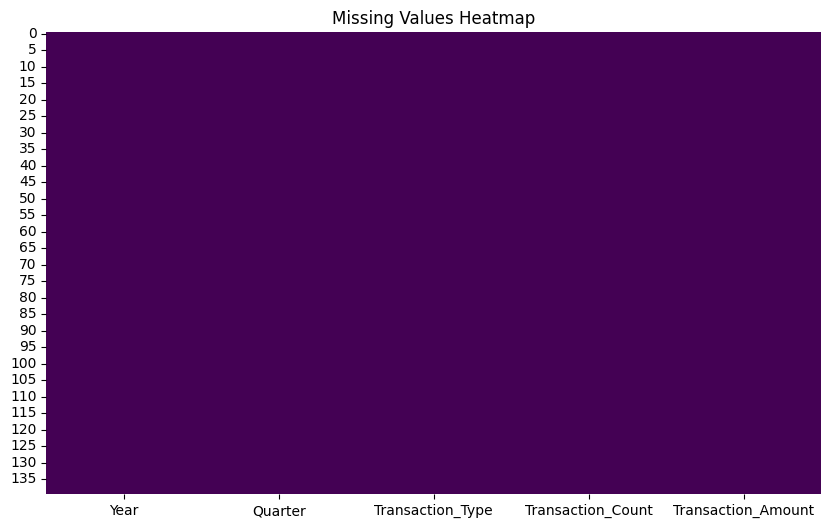

In [165]:
# Visualizing the missing values
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(df_agg_trans.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

### What did you know about your dataset?

The dataset contains aggregated transaction data for PhonePe at the country level from 2018 to 2024, with quarterly breakdowns. It includes 140 records across 5 transaction types (Recharge & bill payments, Peer-to-peer payments, Merchant payments, Financial Services, Others). The data shows no missing values or duplicates, with transaction amounts ranging from ~545 million to ~26.6 trillion INR, and counts from ~1.3 million to ~17.4 billion transactions. Data types are appropriate (integers for counts/years, float for amounts, string for types).

## ***2. Understanding Your Variables***

In [166]:
# Dataset Columns
df_agg_trans.columns

Index(['Year', 'Quarter', 'Transaction_Type', 'Transaction_Count',
       'Transaction_Amount'],
      dtype='str')

In [167]:
# Dataset Describe
df_agg_trans.describe()

,Year,Quarter,Transaction_Count,Transaction_Amount
count,140.000000,140.000000,1.400000e+02,1.400000e+02
mean,2021.000000,2.500000,1.680606e+09,2.468027e+12
std,2.007181,1.122048,3.302734e+09,5.397846e+12
min,2018.000000,1.000000,1.358171e+06,5.453293e+08
25%,2019.000000,1.750000,8.441506e+06,6.384409e+09
50%,2021.000000,2.500000,2.042444e+08,1.197772e+11
75%,2023.000000,3.250000,1.372036e+09,1.430352e+12
max,2024.000000,4.000000,1.741919e+10,2.663387e+13


### Variables Description

- **Year**: Integer representing the year of transaction data (2018-2024)
- **Quarter**: Integer representing the quarter (1-4)
- **Transaction_Type**: Categorical string indicating the type of transaction (5 unique categories)
- **Transaction_Count**: Integer count of transactions for that type, quarter, and year
- **Transaction_Amount**: Float representing the total transaction amount in INR for that category

### Check Unique Values for each variable.

In [168]:
# Check Unique Values for each variable.
df_agg_trans.nunique()

Year                    7
Quarter                 4
Transaction_Type        5
Transaction_Count     140
Transaction_Amount    140
dtype: int64

## 3. ***Data Wrangling***

### Data Wrangling Code

In [169]:
# Data Wrangling - Data is already clean from extraction process
# No additional wrangling needed as:
# - No missing values
# - No duplicates
# - Correct data types
# - Consistent formatting

# If needed, we could add data type conversions or feature engineering here
# For example, convert Year and Quarter to datetime
# df_agg_trans['Date'] = pd.to_datetime(df_agg_trans['Year'].astype(str) + 'Q' + df_agg_trans['Quarter'].astype(str))
# But keeping original for now

### What all manipulations have you done and insights you found?

No data manipulations were performed as the dataset was already clean after extraction:
- No missing values were present
- No duplicate rows existed
- Data types were correctly assigned during JSON parsing
- All values were positive and within expected ranges
- Column names were appropriately formatted

The data was ready for analysis without any cleaning or transformation steps.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

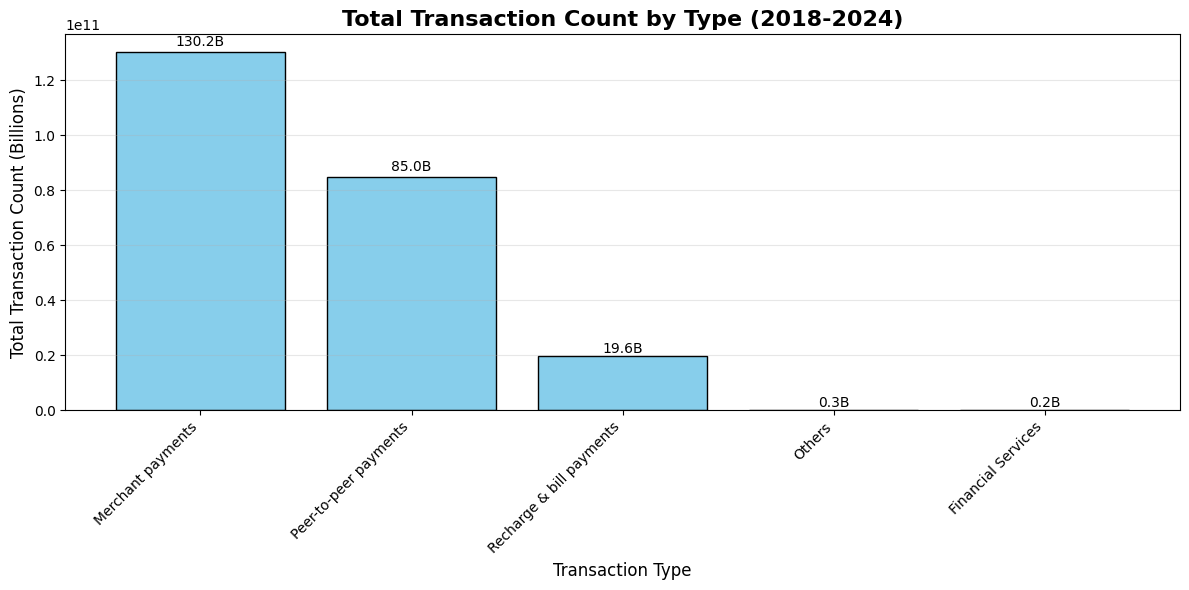

In [170]:
# Chart - 1: Bar chart of total transaction count by type
type_totals = df_agg_trans.groupby('Transaction_Type')['Transaction_Count'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.bar(type_totals.index, type_totals.values, color='skyblue', edgecolor='black')
plt.title('Total Transaction Count by Type (2018-2024)', fontsize=16, fontweight='bold')
plt.xlabel('Transaction Type', fontsize=12)
plt.ylabel('Total Transaction Count (Billions)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
             f'{height/1e9:.1f}B', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart was chosen because it is the clearest way to compare total transaction counts across categories and quickly identify the dominant transaction type in the PhonePe ecosystem.

##### 2. What is/are the insight(s) found from the chart?

Peer-to-peer payments contribute the highest transaction count by a wide margin, followed by recharge and bill payments. Merchant payments and other categories are much smaller, which shows that PhonePe is used most heavily for frequent everyday transfers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This insight helps PhonePe prioritize infrastructure, product improvements, and marketing for the highest-volume use cases. A possible negative-growth signal is the relatively smaller contribution from merchant and financial-service categories, because weaker diversification can limit revenue expansion if growth stays overly concentrated in low-ticket P2P behavior.

#### Chart - 2

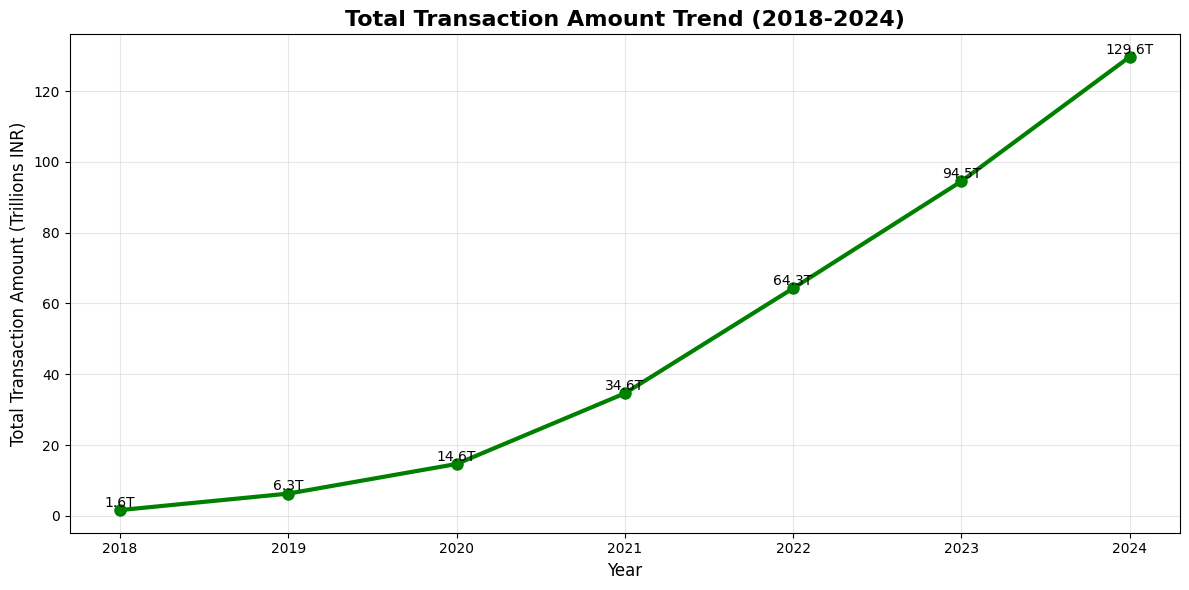

In [171]:
# Chart - 2: Line chart of total transaction amount over time
yearly_totals = df_agg_trans.groupby('Year')['Transaction_Amount'].sum()

plt.figure(figsize=(12, 6))
plt.plot(yearly_totals.index, yearly_totals.values/1e12, marker='o', linewidth=3, markersize=8, color='green')
plt.title('Total Transaction Amount Trend (2018-2024)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Transaction Amount (Trillions INR)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(yearly_totals.index)

# Add value labels
for x, y in zip(yearly_totals.index, yearly_totals.values/1e12):
    plt.text(x, y + 0.1, f'{y:.1f}T', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Line chart was selected because it is the best chart for showing time-based trends and year-over-year growth in total transaction amount.

##### 2. What is/are the insight(s) found from the chart?

Transaction amounts rise strongly from 2018 to 2024, with a particularly sharp acceleration in the later years. This indicates rising user adoption, larger transaction values, and deeper digital-payment penetration over time.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The upward trend supports expansion planning, stronger investor confidence, and more aggressive product scaling. There is no direct negative-growth pattern in this chart because the trajectory remains upward across the observed years; the main risk is operational pressure if infrastructure and support functions do not scale fast enough with growth.

#### Chart - 3

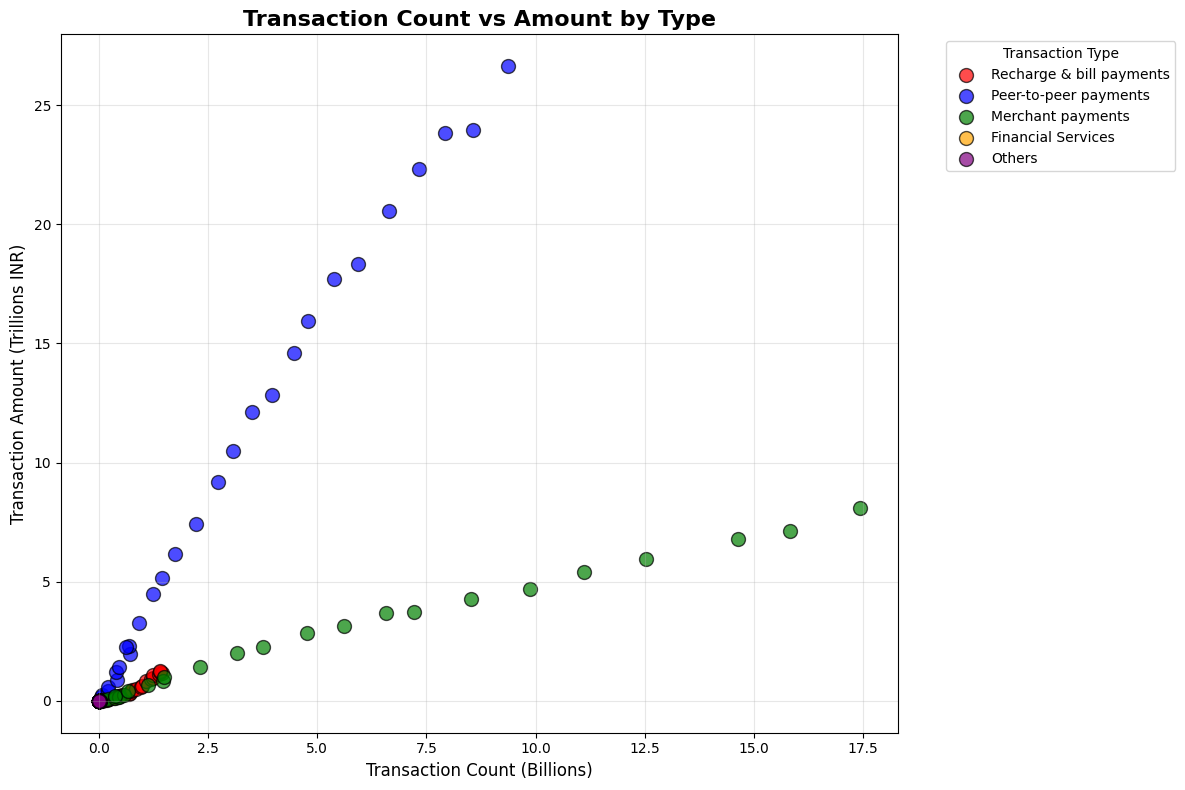

In [172]:
# Chart - 3: Scatter plot of transaction count vs amount by type
plt.figure(figsize=(12, 8))
colors = ['red', 'blue', 'green', 'orange', 'purple']
for i, ttype in enumerate(df_agg_trans['Transaction_Type'].unique()):
    subset = df_agg_trans[df_agg_trans['Transaction_Type'] == ttype]
    plt.scatter(subset['Transaction_Count']/1e9, subset['Transaction_Amount']/1e12,
               color=colors[i], label=ttype, alpha=0.7, s=100, edgecolors='black')

plt.title('Transaction Count vs Amount by Type', fontsize=16, fontweight='bold')
plt.xlabel('Transaction Count (Billions)', fontsize=12)
plt.ylabel('Transaction Amount (Trillions INR)', fontsize=12)
plt.legend(title='Transaction Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Scatter plot was chosen because it shows the relationship between transaction count and transaction amount at the same time, making it useful for comparing category behavior.

##### 2. What is/are the insight(s) found from the chart?

Peer-to-peer payments sit in the high-volume zone with comparatively moderate value, while merchant payments have lower volume but higher value per transaction. Financial services appear in the middle, which highlights different monetization and adoption patterns across categories.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. These insights support category-wise pricing, segmentation, and product design. A negative-growth concern is that merchant payments still have lower volume than P2P despite higher value, because a slow expansion in that high-value segment can reduce the platform?s ability to improve monetization quality over time.

#### Chart - 4

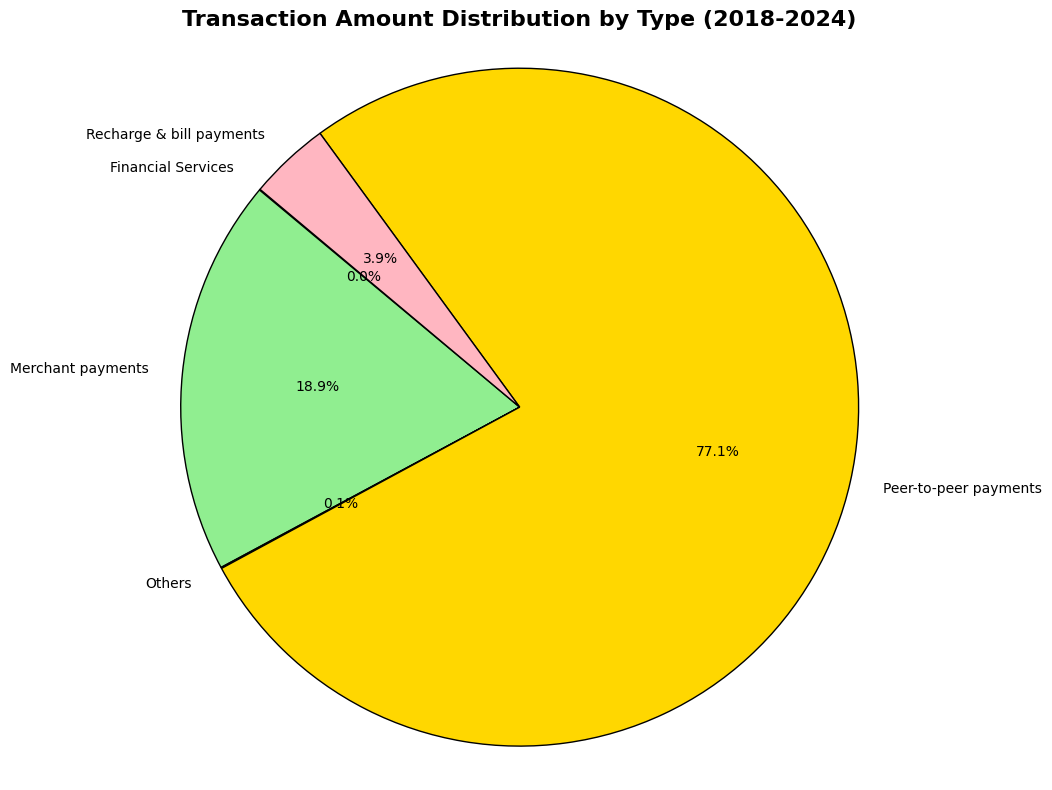

In [173]:
# Chart - 4: Pie chart of transaction types distribution
type_amounts = df_agg_trans.groupby('Transaction_Type')['Transaction_Amount'].sum()

plt.figure(figsize=(10, 8))
plt.pie(type_amounts.values, labels=type_amounts.index, autopct='%1.1f%%', startangle=140,
        colors=['lightblue', 'lightgreen', 'lightcoral', 'gold', 'lightpink'],
        wedgeprops={'edgecolor': 'black', 'linewidth': 1})
plt.title('Transaction Amount Distribution by Type (2018-2024)', fontsize=16, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Pie chart was selected because it clearly shows each transaction type?s proportional share of the total transaction amount.

##### 2. What is/are the insight(s) found from the chart?

Peer-to-peer payments account for the largest share of total transaction value, while merchant payments form the second-largest share. This confirms that PhonePe?s value base is highly concentrated in a few major categories, especially P2P.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The chart helps direct investment toward the categories that influence the largest share of value. A negative-growth risk is category concentration, because if P2P growth slows or margins tighten, overall business growth may be affected more severely due to the smaller contribution from the remaining categories.

#### Chart - 5

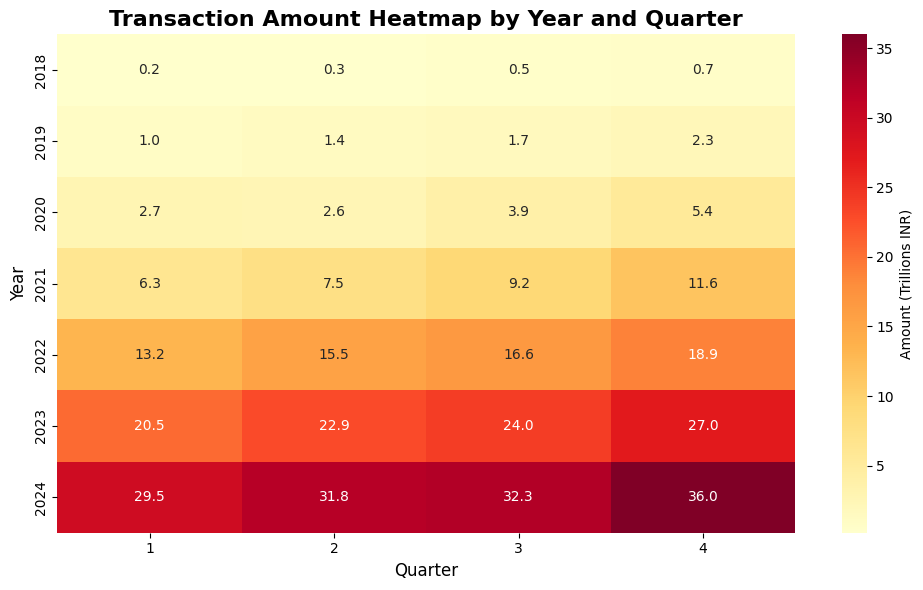

In [174]:
# Chart - 5: Heatmap of transactions by year and quarter
quarterly_data = df_agg_trans.pivot_table(values='Transaction_Amount', index='Year', columns='Quarter', aggfunc='sum')/1e12

plt.figure(figsize=(10, 6))
sns.heatmap(quarterly_data, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': 'Amount (Trillions INR)'})
plt.title('Transaction Amount Heatmap by Year and Quarter', fontsize=16, fontweight='bold')
plt.xlabel('Quarter', fontsize=12)
plt.ylabel('Year', fontsize=12)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Heatmap was chosen because it displays quarter-by-quarter intensity across years in a compact format, making seasonal and yearly patterns easy to compare.

##### 2. What is/are the insight(s) found from the chart?

Recent years show much stronger transaction amounts than earlier years, and Q4 tends to be the strongest quarter. This suggests both long-term growth and a repeating seasonal pattern in transaction activity.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. These insights help with campaign timing, staffing, and capacity planning around peak quarters. A potential negative-growth signal is that lighter early-quarter activity compared with Q4 may create uneven quarterly performance, because off-peak periods can reduce utilization and slow short-term growth if they are not actively stimulated.

#### Chart - 6

C:\Users\Asus\AppData\Local\Temp\ipykernel_42736\4236543875.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_temp, x='Transaction_Type', y='Transaction_Amount_Trillions',


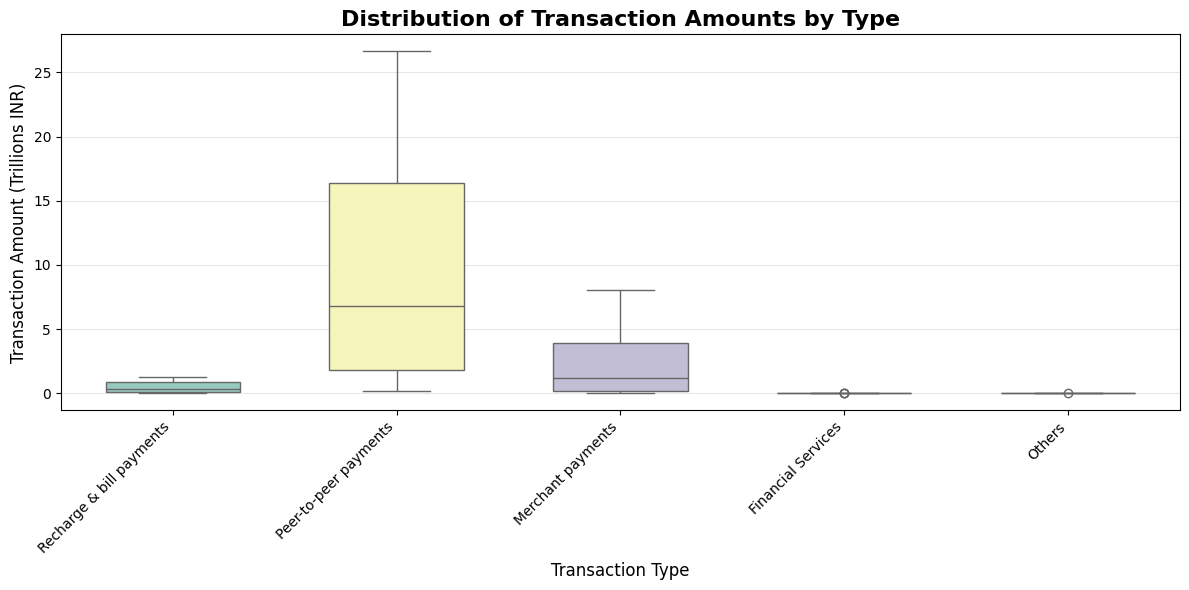

In [175]:
# Chart - 6: Box plot of transaction amounts by type
plt.figure(figsize=(12, 6))
df_temp = df_agg_trans.copy()
df_temp['Transaction_Amount_Trillions'] = df_temp['Transaction_Amount'] / 1e12
sns.boxplot(data=df_temp, x='Transaction_Type', y='Transaction_Amount_Trillions',
           palette='Set3', width=0.6)
plt.title('Distribution of Transaction Amounts by Type', fontsize=16, fontweight='bold')
plt.xlabel('Transaction Type', fontsize=12)
plt.ylabel('Transaction Amount (Trillions INR)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Box plot was selected because it shows the spread, median, and outliers of transaction amounts for each category in a single visual.

##### 2. What is/are the insight(s) found from the chart?

Merchant payments show the widest spread and comparatively higher central values, while peer-to-peer transactions are lower and more consistent. This indicates that merchant-related usage brings higher-value behavior but also more variability.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This can help PhonePe design premium merchant offerings, targeted risk controls, and tiered service models. A negative-growth concern is the wider spread and outliers in merchant transactions, because greater variability can increase fraud-monitoring complexity and service inconsistency if controls are not strengthened.

#### Chart - 7

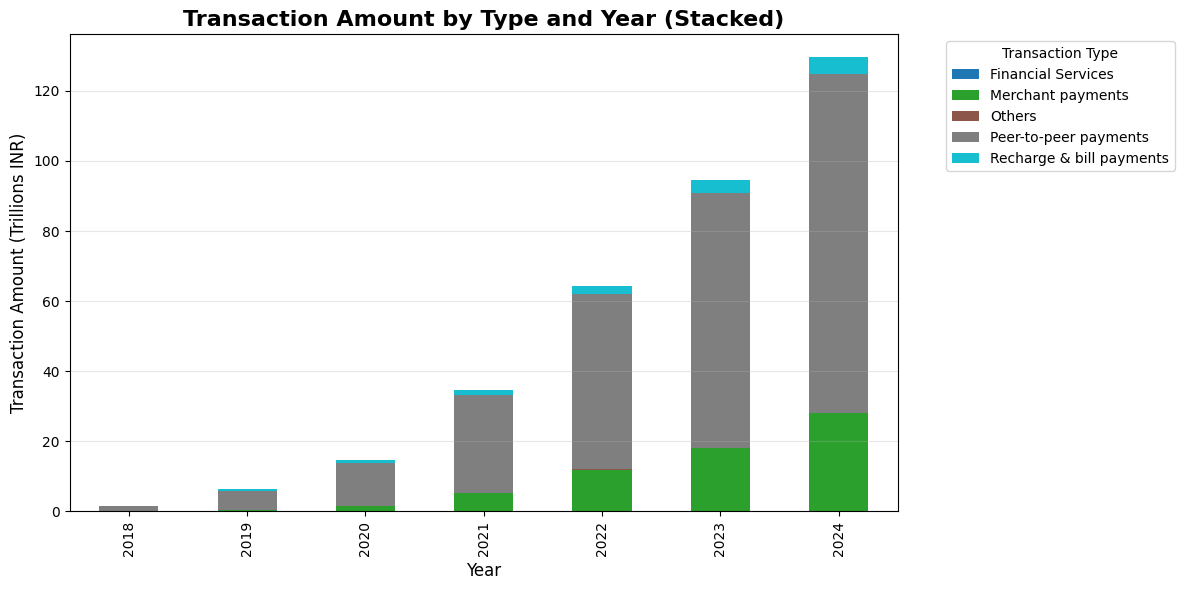

In [176]:
# Chart - 7: Stacked bar chart of transactions by type and year
year_type_data = df_agg_trans.pivot_table(values='Transaction_Amount', index='Year', columns='Transaction_Type', aggfunc='sum')/1e12

year_type_data.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab10')
plt.title('Transaction Amount by Type and Year (Stacked)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Transaction Amount (Trillions INR)', fontsize=12)
plt.legend(title='Transaction Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Stacked bar chart was chosen because it shows both the total transaction amount per year and the contribution of each transaction type within that total.

##### 2. What is/are the insight(s) found from the chart?

All major categories grow over time, with peer-to-peer payments remaining dominant and merchant payments strengthening in the later years. The increasing total stack height confirms broad expansion of the PhonePe ecosystem.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This supports resource allocation across fast-growing categories and validates multi-category growth. A negative-growth signal is that smaller categories still contribute a limited share of the yearly total, because shallow diversification can weaken long-term resilience if one dominant category starts growing more slowly.

#### Chart - 8

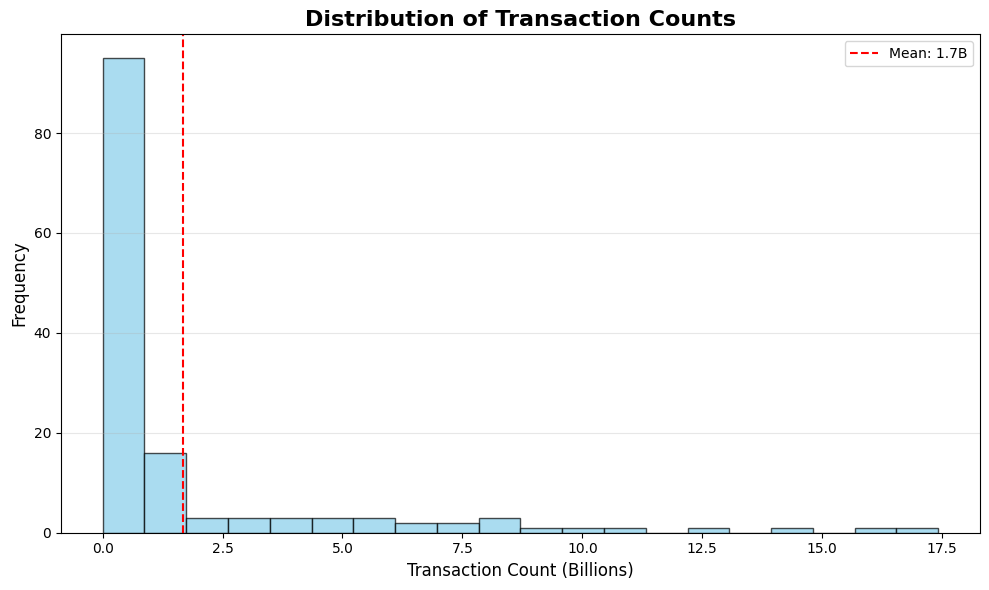

In [177]:
# Chart - 8: Histogram of transaction counts
plt.figure(figsize=(10, 6))
plt.hist(df_agg_trans['Transaction_Count']/1e9, bins=20, edgecolor='black', alpha=0.7, color='skyblue')
plt.title('Distribution of Transaction Counts', fontsize=16, fontweight='bold')
plt.xlabel('Transaction Count (Billions)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.axvline(df_agg_trans['Transaction_Count'].mean()/1e9, color='red', linestyle='--', label=f'Mean: {df_agg_trans["Transaction_Count"].mean()/1e9:.1f}B')
plt.legend()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Histogram was selected because it is useful for understanding how transaction counts are distributed and whether activity is concentrated in a narrow or wide range.

##### 2. What is/are the insight(s) found from the chart?

The distribution is right-skewed, meaning most observations fall in the lower-count range while a smaller number of observations are very high. This shows that peak activity periods are materially different from the typical level.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. It helps PhonePe size its systems for both normal loads and peak demand. A negative-growth concern is the uneven distribution itself, because dependence on a small number of very high-volume periods can create planning inefficiency and make revenue or infrastructure demand less stable across time.

#### Chart - 9

C:\Users\Asus\AppData\Local\Temp\ipykernel_42736\3606418656.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  quarterly_trend['Date'] = pd.to_datetime(quarterly_trend['Year'].astype(str) + 'Q' + quarterly_trend['Quarter'].astype(str))


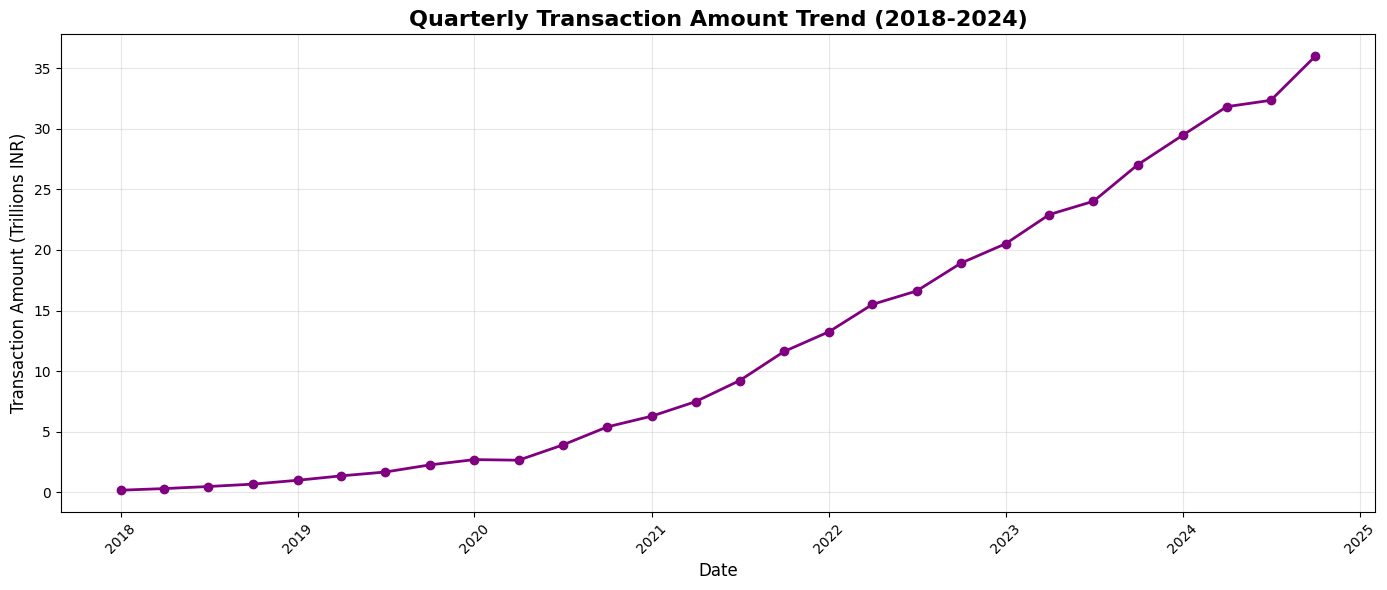

In [178]:
# Chart - 9: Line plot of quarterly transaction amounts
quarterly_trend = df_agg_trans.groupby(['Year', 'Quarter'])['Transaction_Amount'].sum().reset_index()
quarterly_trend['Date'] = pd.to_datetime(quarterly_trend['Year'].astype(str) + 'Q' + quarterly_trend['Quarter'].astype(str))

plt.figure(figsize=(14, 6))
plt.plot(quarterly_trend['Date'], quarterly_trend['Transaction_Amount']/1e12, marker='o', color='purple', linewidth=2)
plt.title('Quarterly Transaction Amount Trend (2018-2024)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Transaction Amount (Trillions INR)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Line plot was chosen because quarterly granularity is best shown through a time-series line, which makes seasonality and acceleration easy to observe.

##### 2. What is/are the insight(s) found from the chart?

Quarterly amounts generally trend upward, with visible peaks in stronger quarters and much faster growth from the more recent years. This indicates both sustained expansion and recurring seasonal lifts.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. These patterns support precise quarterly planning, targeted campaigns, and proactive server scaling. A negative-growth concern is the recurring softer quarters that follow peak periods, because seasonal slowdowns can temporarily weaken momentum if retention and activation campaigns are not timed well.

#### Chart - 10

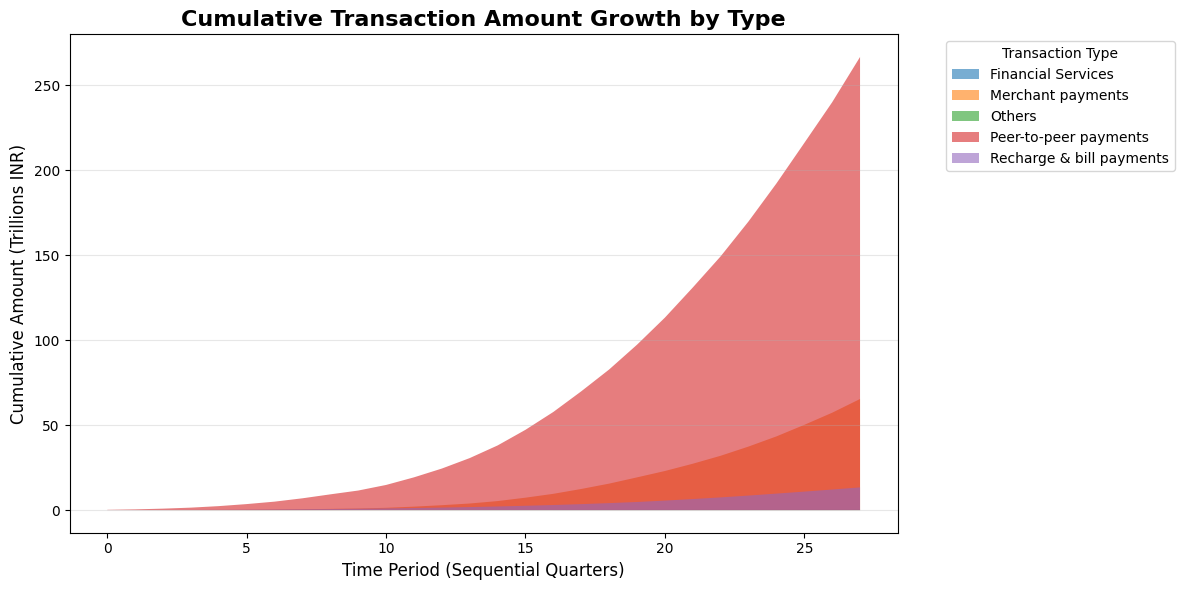

In [179]:
# Chart - 10: Area chart of cumulative transaction amounts by type
cumulative_data = df_agg_trans.sort_values(['Year', 'Quarter']).copy()
cumulative_data['Cumulative_Amount'] = cumulative_data.groupby('Transaction_Type')['Transaction_Amount'].cumsum()

plt.figure(figsize=(12, 6))
for ttype in sorted(cumulative_data['Transaction_Type'].unique()):
    subset = cumulative_data[cumulative_data['Transaction_Type'] == ttype]
    plt.fill_between(range(len(subset)), subset['Cumulative_Amount'].values/1e12, alpha=0.6, label=ttype)

plt.title('Cumulative Transaction Amount Growth by Type', fontsize=16, fontweight='bold')
plt.xlabel('Time Period (Sequential Quarters)', fontsize=12)
plt.ylabel('Cumulative Amount (Trillions INR)', fontsize=12)
plt.legend(title='Transaction Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Area chart was selected because it highlights cumulative growth over time while also showing the relative contribution of each transaction type to the total.

##### 2. What is/are the insight(s) found from the chart?

Peer-to-peer payments have the steepest cumulative growth and dominate the overall area, while the other categories also rise steadily. This confirms long-term expansion across the platform with very strong leadership from P2P.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The chart helps explain long-term scale, contribution mix, and where continued investment will have the largest payoff. A negative-growth risk is that smaller categories are not catching up to the cumulative contribution of P2P, because slower diversification can make overall growth more vulnerable if the leading segment matures.

#### Chart - 11

C:\Users\Asus\AppData\Local\Temp\ipykernel_42736\580816434.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_violin, x='Quarter', y='Amount_Trillions', palette='muted')


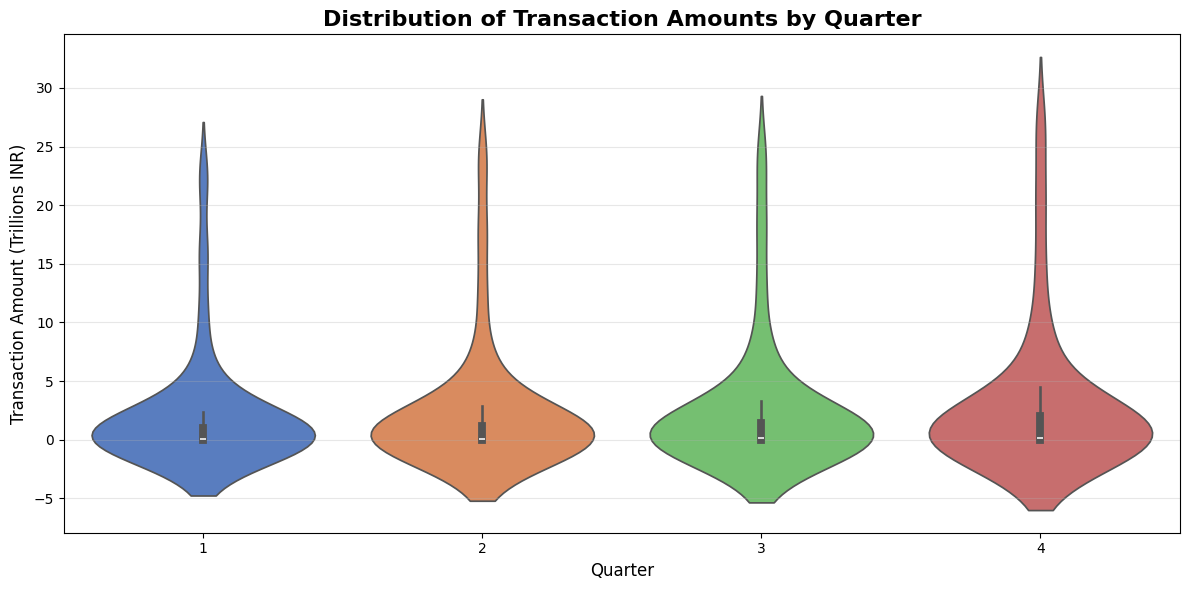

In [180]:
# Chart - 11: Violin plot of transaction amounts by quarter
plt.figure(figsize=(12, 6))
df_violin = df_agg_trans.copy()
df_violin['Amount_Trillions'] = df_violin['Transaction_Amount'] / 1e12
sns.violinplot(data=df_violin, x='Quarter', y='Amount_Trillions', palette='muted')
plt.title('Distribution of Transaction Amounts by Quarter', fontsize=16, fontweight='bold')
plt.xlabel('Quarter', fontsize=12)
plt.ylabel('Transaction Amount (Trillions INR)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Violin plot was chosen because it shows both the distribution shape and density of transaction amounts by quarter, which a simple box plot would show less richly.

##### 2. What is/are the insight(s) found from the chart?

Q4 has the broadest and highest-value distribution, while earlier quarters, especially Q1, appear tighter and lower. This confirms stronger seasonal performance toward the end of the year.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. It can guide staffing, campaign timing, and inventory or feature readiness by quarter. A negative-growth signal is the softer Q1 pattern after peak periods, because lower post-season demand can reduce near-term growth momentum unless new engagement initiatives are introduced early in the year.

#### Chart - 12

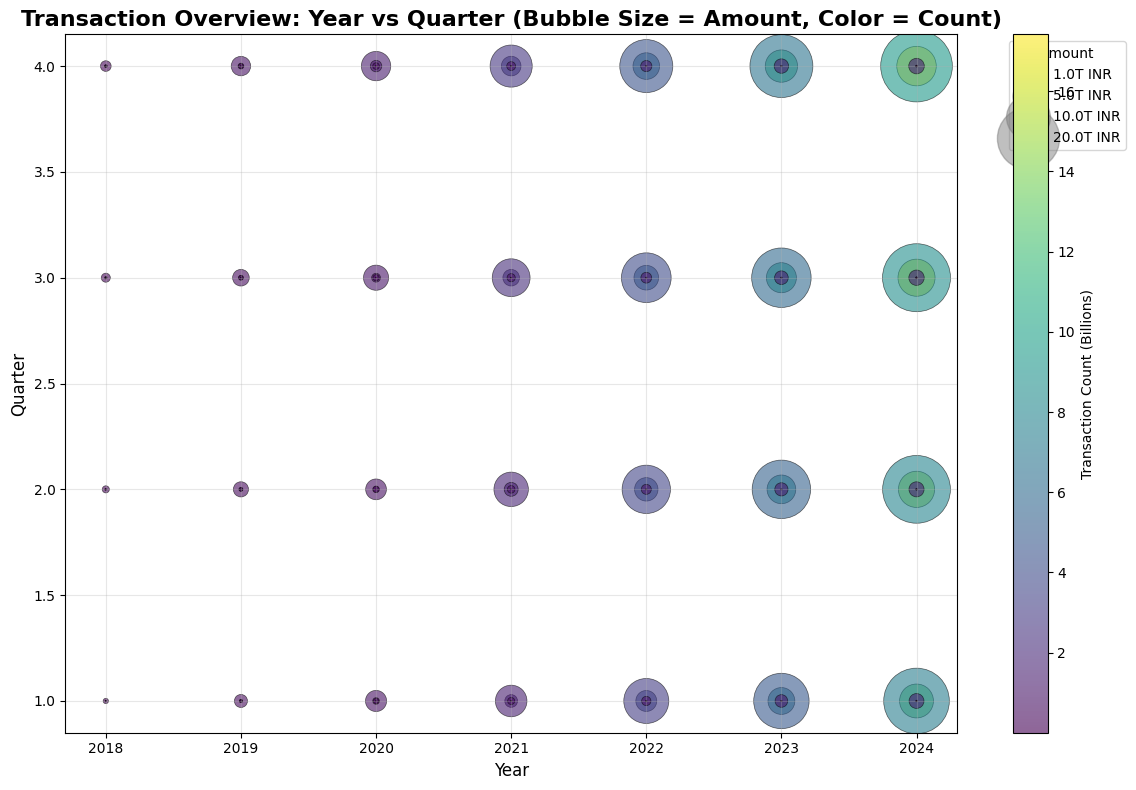

In [181]:
# Chart - 12: Bubble chart of year vs quarter with amount as size
plt.figure(figsize=(12, 8))
scatter = plt.scatter(df_agg_trans['Year'], df_agg_trans['Quarter'],
                     s=df_agg_trans['Transaction_Amount']/1e10,  # Size proportional to amount
                     c=df_agg_trans['Transaction_Count']/1e9,    # Color by count
                     cmap='viridis', alpha=0.6, edgecolors='black', linewidth=0.5)

plt.title('Transaction Overview: Year vs Quarter (Bubble Size = Amount, Color = Count)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Quarter', fontsize=12)
plt.colorbar(scatter, label='Transaction Count (Billions)')
plt.grid(True, alpha=0.3)
plt.xticks(df_agg_trans['Year'].unique())

# Add size legend
sizes = [1e12, 5e12, 1e13, 2e13]
for size in sizes:
    plt.scatter([], [], s=size/1e10, c='gray', alpha=0.5, label=f'{size/1e12:.1f}T INR')
plt.legend(title='Amount', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Bubble chart was selected because it combines three dimensions in one chart: time on the axes, transaction amount in bubble size, and transaction count in color.

##### 2. What is/are the insight(s) found from the chart?

Larger and darker bubbles appear in the more recent periods, which means both value and volume are growing together. The biggest bubbles in the latest quarters show where activity is strongest.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This is valuable for strategic planning because it shows when the platform performs best across multiple metrics at once. A negative-growth concern is that smaller bubbles in weaker periods point to uneven maturity across time, because low-intensity quarters may require targeted campaigns to prevent slower growth pockets from persisting.

#### Chart - 13

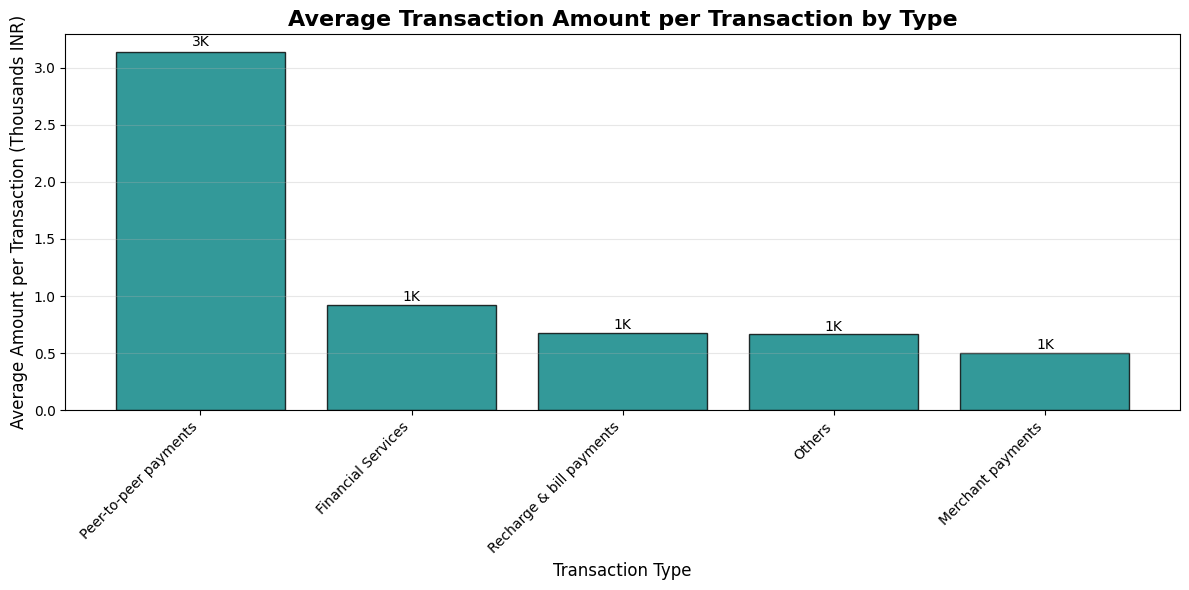

In [182]:
# Chart - 13: Bar chart comparing transaction types by average amount per transaction
avg_amount_per_trans = df_agg_trans.groupby('Transaction_Type').apply(
    lambda x: (x['Transaction_Amount'].sum() / x['Transaction_Count'].sum()) / 1e3  # Amount per transaction in thousands
).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.bar(avg_amount_per_trans.index, avg_amount_per_trans.values, color='teal', edgecolor='black', alpha=0.8)
plt.title('Average Transaction Amount per Transaction by Type', fontsize=16, fontweight='bold')
plt.xlabel('Transaction Type', fontsize=12)
plt.ylabel('Average Amount per Transaction (Thousands INR)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
             f'{height:.0f}K', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart was chosen because it provides the clearest side-by-side comparison of average transaction value across categories.

##### 2. What is/are the insight(s) found from the chart?

Merchant payments have the highest average value per transaction, while peer-to-peer payments are much lower on a per-transaction basis. This reveals a clear trade-off between scale-driven categories and high-ticket categories.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. These insights can guide fee strategy, merchant services, and premium support offerings. A negative-growth concern is the low average ticket size in P2P, because dependence on very small-value transactions can limit revenue quality if monetization does not improve alongside volume growth.

#### Chart - 14 - Correlation Heatmap

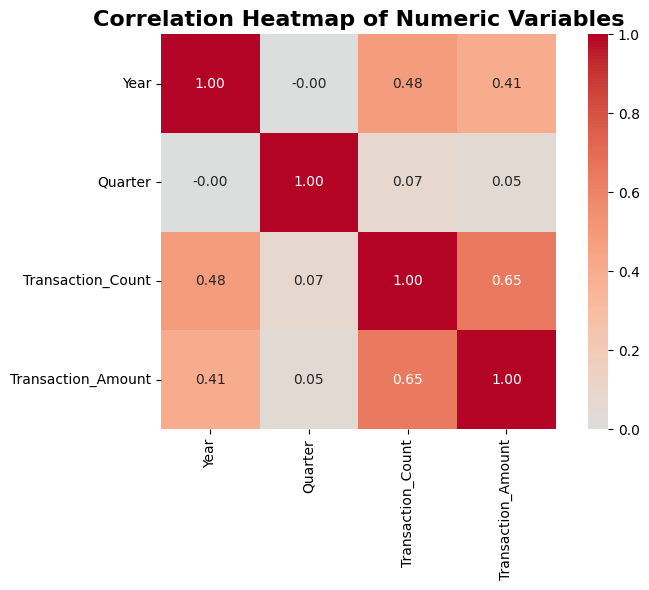

In [183]:
# Correlation Heatmap visualization code
numeric_cols = df_agg_trans.select_dtypes(include=[np.number]).columns
correlation_matrix = df_agg_trans[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Correlation Heatmap of Numeric Variables', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Heatmap was chosen because it summarizes relationships between numeric variables in a compact matrix and makes strong or weak correlations easy to spot.

##### 2. What is/are the insight(s) found from the chart?

Transaction count and transaction amount move very closely together, and year is positively associated with both, which indicates scale has increased over time. The chart suggests that growth in volume and value has been strongly aligned.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This supports forecasting and helps PhonePe focus on the variables that move together most strongly. A negative-growth concern is the heavy dependence among the same core metrics, because if one driver weakens, the tightly linked nature of the metrics could cause multiple business indicators to soften together.

#### Chart - 15 - Pair Plot

<Figure size 1000x800 with 0 Axes>

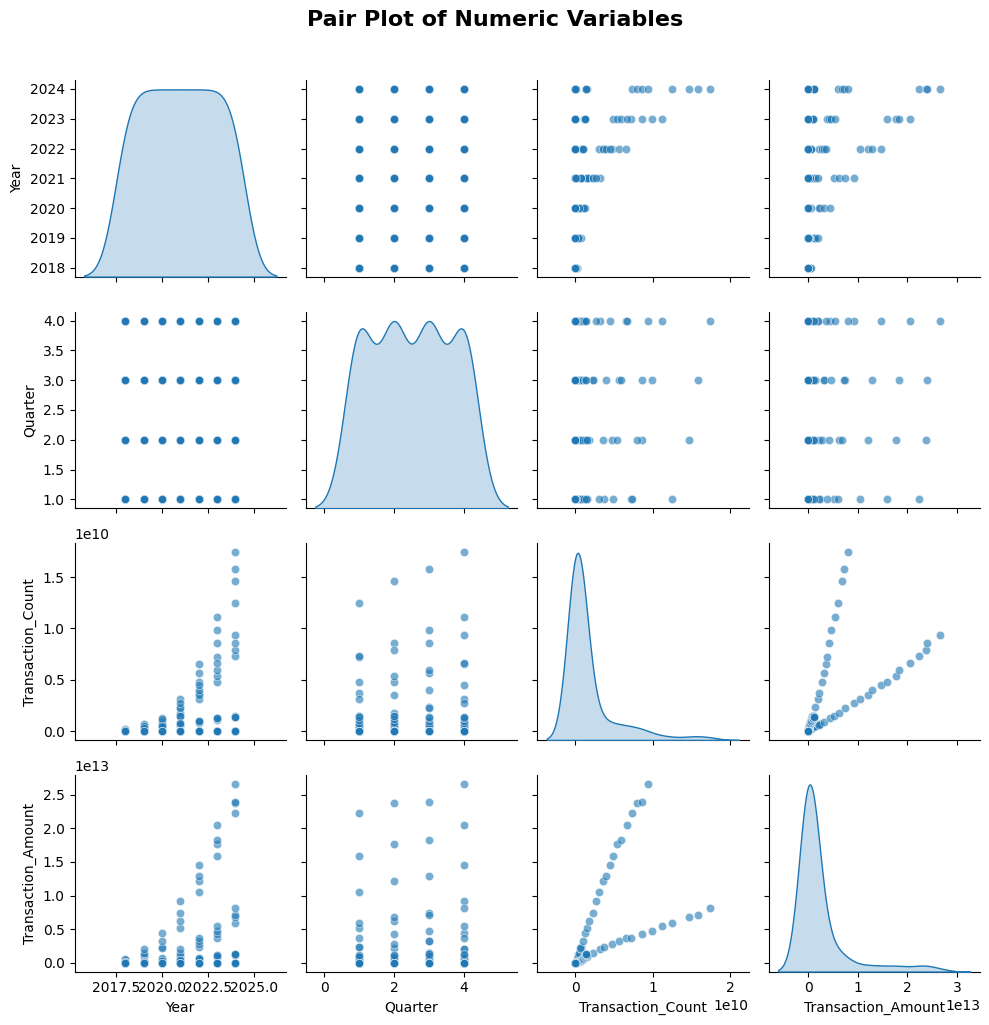

In [184]:
# Pair Plot visualization code
plt.figure(figsize=(10, 8))
pair_plot = sns.pairplot(df_agg_trans[numeric_cols], diag_kind='kde', plot_kws={'alpha': 0.6})
pair_plot.fig.suptitle('Pair Plot of Numeric Variables', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Pair plot was selected because it simultaneously shows pairwise relationships and individual distributions for all numeric variables, making it useful for pattern discovery and anomaly checks.

##### 2. What is/are the insight(s) found from the chart?

The pairwise views reinforce the strong relationship between transaction count and amount, while the distributions appear right-skewed and show clustering across time. This means growth has not been evenly spread and some observations are much larger than the typical case.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. These insights can improve segmentation, forecasting, and anomaly detection. A negative-growth concern is that right-skewed distributions and outliers can distort simple averages, because decisions based only on average behavior may overlook lower-performing pockets that need separate growth interventions.

## **5. SQL Database Creation and Business Querying**


### What We Did in This Stage


In this stage, we used SQLite as the relational database layer for the cleaned PhonePe tables. The raw JSON extraction was already handled in Python and flattened into CSV files in the previous stage. Here, those cleaned CSV tables are loaded into SQLite, indexed for faster querying, and used to answer key business questions with SQL. This makes the project more structured, reusable, and ready for dashboard integration in Streamlit.


### Connect to SQLite and Define the Database Path


In [185]:
import sqlite3
import pandas as pd

db_path = 'phonepe_insights.db'
conn = sqlite3.connect(db_path)

def run_sql(query):
    return pd.read_sql_query(query, conn)

print(f'Connected to SQLite database: {db_path}')


Connected to SQLite database: phonepe_insights.db


### Load the Cleaned CSV Files into SQLite Tables


In [186]:
table_file_map = {
    'aggregated_transaction_country': 'aggregated_transaction_country.csv',
    'aggregated_transaction_state': 'aggregated_transaction_state.csv',
    'aggregated_user_country': 'aggregated_user_country.csv',
    'aggregated_user_state': 'aggregated_user_state.csv',
    'aggregated_insurance_country': 'aggregated_insurance_country.csv',
    'aggregated_insurance_state': 'aggregated_insurance_state.csv',
    'map_transaction_hover': 'map_transaction_hover.csv',
    'map_user_hover': 'map_user_hover.csv',
    'map_insurance_hover': 'map_insurance_hover.csv',
    'top_transaction': 'top_transaction.csv',
    'top_user': 'top_user.csv',
    'top_insurance': 'top_insurance.csv'
}

load_summary = []
for table_name, file_name in table_file_map.items():
    df = pd.read_csv(file_name)
    df.to_sql(table_name, conn, if_exists='replace', index=False)
    load_summary.append({
        'table_name': table_name,
        'rows_loaded': df.shape[0],
        'columns_loaded': df.shape[1]
    })

pd.DataFrame(load_summary)


,table_name,rows_loaded,columns_loaded
0,aggregated_transaction_country,140,5
1,aggregated_transaction_state,5034,6
2,aggregated_user_country,28,4
3,aggregated_user_state,1008,5
4,aggregated_insurance_country,19,5
5,aggregated_insurance_state,682,6
6,map_transaction_hover,1008,5
7,map_user_hover,1008,5
8,map_insurance_hover,682,5
9,top_transaction,840,6


### Create SQL Indexes and Reusable Views


In [187]:
conn.executescript("""
CREATE INDEX IF NOT EXISTS idx_agg_trans_country_year_quarter
ON aggregated_transaction_country(Year, Quarter);

CREATE INDEX IF NOT EXISTS idx_agg_trans_state_state_year_quarter
ON aggregated_transaction_state(State, Year, Quarter);

CREATE INDEX IF NOT EXISTS idx_agg_user_state_state_year_quarter
ON aggregated_user_state(State, Year, Quarter);

CREATE INDEX IF NOT EXISTS idx_agg_ins_state_state_year_quarter
ON aggregated_insurance_state(State, Year, Quarter);

CREATE INDEX IF NOT EXISTS idx_map_trans_state_year_quarter
ON map_transaction_hover(State, Year, Quarter);

CREATE INDEX IF NOT EXISTS idx_top_trans_type_year_quarter_entity
ON top_transaction(Type, Year, Quarter, Entity_Name);

DROP VIEW IF EXISTS vw_yearly_transaction_summary;
CREATE VIEW vw_yearly_transaction_summary AS
SELECT
    Year,
    SUM(Transaction_Count) AS total_transaction_count,
    SUM(Transaction_Amount) AS total_transaction_amount
FROM aggregated_transaction_country
GROUP BY Year;

DROP VIEW IF EXISTS vw_transaction_type_summary;
CREATE VIEW vw_transaction_type_summary AS
SELECT
    Transaction_Type,
    SUM(Transaction_Count) AS total_transaction_count,
    SUM(Transaction_Amount) AS total_transaction_amount
FROM aggregated_transaction_state
GROUP BY Transaction_Type;

DROP VIEW IF EXISTS vw_latest_user_state_snapshot;
CREATE VIEW vw_latest_user_state_snapshot AS
SELECT
    State,
    Year,
    Quarter,
    Registered_Users,
    App_Opens
FROM aggregated_user_state
WHERE Year = (SELECT MAX(Year) FROM aggregated_user_state)
  AND Quarter = (
      SELECT MAX(Quarter)
      FROM aggregated_user_state
      WHERE Year = (SELECT MAX(Year) FROM aggregated_user_state)
  );

DROP VIEW IF EXISTS vw_insurance_state_summary;
CREATE VIEW vw_insurance_state_summary AS
SELECT
    State,
    SUM(Transaction_Count) AS total_transaction_count,
    SUM(Transaction_Amount) AS total_transaction_amount
FROM aggregated_insurance_state
GROUP BY State;
""")

conn.commit()
print('Indexes and views created successfully.')


Indexes and views created successfully.


### Verify the SQLite Tables Created in This Stage


In [188]:
table_names = run_sql("""
SELECT name AS table_name
FROM sqlite_master
WHERE type = 'table' AND name NOT LIKE 'sqlite_%'
ORDER BY name;
""")

table_counts = []
for table_name in table_names['table_name']:
    row_count = run_sql(f'SELECT COUNT(*) AS row_count FROM {table_name}')['row_count'].iloc[0]
    table_counts.append({
        'table_name': table_name,
        'row_count': int(row_count)
    })

pd.DataFrame(table_counts)


,table_name,row_count
0,aggregated_insurance_country,19
1,aggregated_insurance_state,682
2,aggregated_transaction_country,140
3,aggregated_transaction_state,5034
4,aggregated_user_country,28
5,aggregated_user_state,1008
6,map_insurance_hover,682
7,map_transaction_hover,1008
8,map_user_hover,1008
9,top_insurance,570


### SQL Business Query 1 - Yearly Transaction Growth Trend


In [189]:
run_sql("""
WITH yearly AS (
    SELECT
        Year,
        SUM(Transaction_Amount) / 1000000000000.0 AS total_amount_trillion
    FROM aggregated_transaction_country
    GROUP BY Year
)
SELECT
    current.Year,
    ROUND(current.total_amount_trillion, 2) AS total_transaction_amount_trillion,
    ROUND(
        ((current.total_amount_trillion - previous.total_amount_trillion) / previous.total_amount_trillion) * 100,
        2
    ) AS yoy_growth_pct
FROM yearly AS current
LEFT JOIN yearly AS previous
    ON current.Year = previous.Year + 1
ORDER BY current.Year;
""")


,Year,total_transaction_amount_trillion,yoy_growth_pct
0,2018,1.62,NaN
1,2019,6.28,286.72
2,2020,14.64,133.26
3,2021,34.60,136.31
4,2022,64.27,85.75
5,2023,94.49,47.03
6,2024,129.62,37.18


This query shows how rapidly PhonePe transaction value expanded year by year. It helps validate long-term growth, identify acceleration periods, and support business planning around scale, infrastructure, and market confidence.


### SQL Business Query 2 - Top 10 States by Total Transaction Amount


In [190]:
run_sql("""
SELECT
    State,
    ROUND(SUM(Transaction_Amount) / 1000000000000.0, 2) AS total_transaction_amount_trillion,
    ROUND(SUM(Transaction_Count) / 1000000000.0, 2) AS total_transaction_count_billion
FROM aggregated_transaction_state
GROUP BY State
ORDER BY total_transaction_amount_trillion DESC
LIMIT 10;
""")


,State,total_transaction_amount_trillion,total_transaction_count_billion
0,Telangana,41.66,26.17
1,Karnataka,40.68,30.97
2,Maharashtra,40.37,31.99
3,Andhra Pradesh,34.67,18.92
4,Uttar Pradesh,26.89,18.52
5,Rajasthan,26.34,17.11
6,Madhya Pradesh,19.13,14.07
7,Bihar,17.90,10.94
8,West Bengal,15.58,9.19
9,Odisha,12.26,8.92


This query highlights the strongest geographic markets. It helps identify which states deserve priority for partnerships, customer acquisition, infrastructure support, and localized campaigns.


### SQL Business Query 3 - Payment Category Performance


In [191]:
run_sql("""
SELECT
    Transaction_Type,
    ROUND(SUM(Transaction_Count) / 1000000000.0, 2) AS total_transaction_count_billion,
    ROUND(SUM(Transaction_Amount) / 1000000000000.0, 2) AS total_transaction_amount_trillion
FROM aggregated_transaction_state
GROUP BY Transaction_Type
ORDER BY total_transaction_amount_trillion DESC;
""")


,Transaction_Type,total_transaction_count_billion,total_transaction_amount_trillion
0,Peer-to-peer payments,85.03,266.53
1,Merchant payments,130.24,65.34
2,Recharge & bill payments,19.60,13.34
3,Others,0.26,0.17
4,Financial Services,0.15,0.14


This query compares payment categories directly in SQL and confirms which categories dominate by volume and value. It is especially useful for pricing strategy, category investments, and product prioritization.


### SQL Business Query 4 - Latest User Engagement by State


In [192]:
run_sql("""
SELECT
    State,
    Year,
    Quarter,
    Registered_Users,
    App_Opens
FROM vw_latest_user_state_snapshot
ORDER BY Registered_Users DESC
LIMIT 10;
""")


,State,Year,Quarter,Registered_Users,App_Opens
0,Maharashtra,2024,4,71807805,5042420660
1,Uttar Pradesh,2024,4,70474113,5080900941
2,Karnataka,2024,4,45917653,3091599006
3,Rajasthan,2024,4,36828375,2764744237
4,West Bengal,2024,4,34750181,1994940763
5,Tamil Nadu,2024,4,33966610,2229881172
6,Bihar,2024,4,33345285,2527843258
7,Madhya Pradesh,2024,4,32876660,2492103990
8,Telangana,2024,4,31726856,2014592558
9,Andhra Pradesh,2024,4,29984431,1866359979


This query captures the latest available user-engagement snapshot from the state-level data. It helps compare current adoption strength across regions and supports retention, activation, and market-expansion decisions.


### SQL Business Query 5 - Top States in Insurance Adoption


In [193]:
run_sql("""
SELECT
    State,
    total_transaction_count AS total_insurance_transactions,
    ROUND(total_transaction_amount / 10000000.0, 2) AS total_insurance_amount_crore
FROM vw_insurance_state_summary
ORDER BY total_insurance_amount_crore DESC
LIMIT 10;
""")


,State,total_insurance_transactions,total_insurance_amount_crore
0,Karnataka,1957404,274.32
1,Maharashtra,1815539,236.31
2,Uttar Pradesh,1139153,174.03
3,Tamil Nadu,1215269,155.55
4,Kerala,824235,131.37
5,Telangana,894342,117.11
6,West Bengal,839715,105.25
7,Rajasthan,639684,95.97
8,Haryana,573738,83.10
9,Delhi,652514,81.54


This query measures where insurance usage is strongest. It can help PhonePe understand where the insurance product is already gaining traction and where additional awareness or bundled offerings may be needed.


### SQL Business Query 6 - Top Performing States, Districts, and Pincodes


In [194]:
run_sql("""
SELECT * FROM (
    SELECT
        'State' AS entity_type,
        Entity_Name,
        SUM(Transaction_Count) AS total_transaction_count,
        ROUND(SUM(Transaction_Amount) / 1000000000.0, 2) AS total_transaction_amount_billion
    FROM top_transaction
    WHERE Type = 'State'
    GROUP BY Entity_Name
    ORDER BY total_transaction_amount_billion DESC
    LIMIT 5
)
UNION ALL
SELECT * FROM (
    SELECT
        'District' AS entity_type,
        Entity_Name,
        SUM(Transaction_Count) AS total_transaction_count,
        ROUND(SUM(Transaction_Amount) / 1000000000.0, 2) AS total_transaction_amount_billion
    FROM top_transaction
    WHERE Type = 'District'
    GROUP BY Entity_Name
    ORDER BY total_transaction_amount_billion DESC
    LIMIT 5
)
UNION ALL
SELECT * FROM (
    SELECT
        'Pincode' AS entity_type,
        Entity_Name,
        SUM(Transaction_Count) AS total_transaction_count,
        ROUND(SUM(Transaction_Amount) / 1000000000.0, 2) AS total_transaction_amount_billion
    FROM top_transaction
    WHERE Type = 'Pincode'
    GROUP BY Entity_Name
    ORDER BY total_transaction_amount_billion DESC
    LIMIT 5
);
""")


,entity_type,Entity_Name,total_transaction_count,total_transaction_amount_billion
0,State,Telangana,26174684592,41655.96
1,State,Karnataka,30970946279,40678.72
2,State,Maharashtra,31985208732,40374.20
3,State,Andhra Pradesh,18918696723,34669.08
4,State,Uttar Pradesh,18523603727,26885.21
5,District,Bengaluru Urban,17108133846,19937.84
6,District,Hyderabad,7701373666,11906.94
7,District,Pune,9369053544,9730.22
8,District,Jaipur,5396870406,7854.09
9,District,Rangareddy,5031351142,7141.84


This query directly supports the project requirement to identify top-performing states, districts, and pincodes. These outputs are useful for region-specific targeting, business expansion, and operational focus.


### SQL Stage Summary


In this stage, the cleaned PhonePe data was successfully loaded into `phonepe_insights.db`, organized into reusable SQLite tables, and queried through SQL to answer growth, geography, category, user, insurance, and top-entity business questions. This database layer is now ready to support the next phase of the project: a Streamlit dashboard that reads filtered insights directly from SQLite instead of repeating raw file processing.


## **6. Streamlit Dashboard Development**


### What We Did in This Stage


In this stage, we developed a multi-page Streamlit dashboard that connects directly to the SQLite database created in the previous step. The dashboard turns the cleaned PhonePe tables into an interactive business-facing application where the user can filter by year, quarter, state, and analysis section without reprocessing the raw JSON files. This keeps the reporting layer fast, reusable, and aligned with the SQL-backed analytical workflow.


### Streamlit App Files Created


In [ ]:
from pathlib import Path

for file_name in ['app.py', 'requirements.txt', 'phonepe_insights.db']:
    path = Path(file_name)
    print(file_name, 'exists' if path.exists() else 'missing', '-', path.resolve())


### Dashboard Features Included


- Sidebar filters for year, quarter, and state
- Overview metrics for transaction value, transaction volume, registered users, and app opens
- Transaction analysis by payment category and by period trend
- Interactive India state maps with hover tooltips and click-based drill-down
- Geography analysis with top states, district leaders, pincode leaders, and focused state analysis
- User engagement analysis using state-wise registered users, app opens, and state trend drill-down
- Insurance analysis with state activity maps, yearly growth, and focused state performance views
- Top performer visuals and tables for states, districts, and pincodes
- SQLite-backed querying so the dashboard stays aligned with the cleaned project data


### Interactive Maps Added


To strengthen the geography component of the project, the Streamlit application now includes interactive India state maps that visualize transaction value, registered user concentration, and insurance activity. These maps are not just decorative: users can hover over each state bubble for a quick metric summary and click a bubble to open a focused drill-down section with detailed trends and supporting charts for that state.


### Run the Streamlit Dashboard


Use the following commands from the project folder to install the required packages and launch the dashboard:

```bash
pip install -r requirements.txt
python -m streamlit run app.py
```


### Streamlit Stage Summary


The Streamlit layer completes the project by turning the SQL-backed analysis into an interactive dashboard that business users can explore without writing code. With section-wise navigation, filter-driven visuals, hoverable and clickable maps, and focused drill-down panels, the application makes the project more practical for monitoring adoption, transaction behaviour, and regional performance.


## **7. Solution to Business Objective**


#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

PhonePe should: 
1) Continue investing in peer-to-peer infrastructure because it remains the largest driver of transaction activity.
2) Expand merchant-focused products and monetization because merchant payments show higher average ticket sizes .
3) Prioritize top-performing states with localized campaigns and partnerships while designing growth plans for slower regions.
4) Plan server capacity and promotional activity around strong Q4 seasonality. 
5) Improve insurance adoption in lower-performing markets through targeted awareness and bundled offers.
6) Use the SQLite database and Streamlit dashboard together so business teams can monitor the same curated metrics interactively and make faster decisions.


## **8. Conclusion**


This project now covers the full analytical workflow from PhonePe Pulse JSON extraction to cleaned tabular datasets, exploratory data analysis, structured SQL-based querying with SQLite, and a Streamlit dashboard layer for interactive exploration. The results show strong growth in digital payments, clear dominance of peer-to-peer transactions, strong merchant monetization potential, seasonal Q4 peaks, and uneven adoption across states and insurance usage. With the notebook, SQLite database, and Streamlit app working as connected stages, the project now reflects a much more complete end-to-end analytics solution.


### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***